# Experiment 4 - W-estimate skill summary

Presentation figures built from `data/metrics.csv` and the per-cell arrays saved
by `run_experiment_4.py`: an overview (fig1), skill vs array width (fig2 plus the
per-method breakdowns fig2a-2d), skill vs cell latitude (fig3), skill vs
gliders-per-cell (fig4), and skill vs depth per method (fig5a-5d). Every metric is
a plain descriptive statistic (RMS, RMS normalized by the signal std, correlation,
bias) - no thresholds or 'best config' judgements are baked in; those are left to
discuss.

Run in place after `run_experiment_4.py` has populated `data/`.

In [1]:
import os, sys
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

REPO = "/home/edavenport/analysis/tpose24-osse"
HERE = os.path.join(REPO, "experiment_4")
sys.path.insert(0, REPO)
import summary_fig_tools as sft

DATA   = os.path.join(HERE, "data")
SUMDIR = os.path.join(HERE, "summary_figs"); os.makedirs(SUMDIR, exist_ok=True)
plt.rcParams["figure.dpi"] = 120
sft.apply_style()

m = pd.read_csv(os.path.join(DATA, "metrics.csv"))

def load_cell(row):
    """Open the saved w_est/w_model/bias arrays for one metrics row."""
    return xr.open_dataset(os.path.join(HERE, row.nc_path))

print(f"{len(m)} config cells across {m.config.nunique()} configs")
m.head()

120 config cells across 72 configs


,config,family,pattern,width,center_lat,n_gliders_cell,n_gliders_total,cell_height_deg,min_depth,max_depth,...,w_model_mean,norm_rms,n,w_est_mean_se,w_model_mean_se,mean_bias_se,n_eff,n_eff_model,n_eff_est,tau
0,density_2g_w0.25,density,density_2g,0.25,0.5,2,2,1.0,8,120,...,0.000005,0.467382,36936,0.000011,0.000011,0.000004,56.194376,39.109375,40.631454,11.531403
1,density_2g_w0.5,density,density_2g,0.50,0.5,2,2,1.0,8,120,...,0.000004,0.378451,36936,0.000011,0.000012,0.000003,61.140163,34.638662,34.302812,10.598598
2,density_2g_w0.75,density,density_2g,0.75,0.5,2,2,1.0,8,120,...,0.000003,0.391045,36936,0.000011,0.000011,0.000003,54.001354,33.474778,32.102418,11.999699
3,density_2g_w1.0,density,density_2g,1.00,0.5,2,2,1.0,8,120,...,0.000004,0.481063,36936,0.000011,0.000011,0.000004,46.685582,32.655984,30.909496,13.880088
4,density_2g_w1.5,density,density_2g,1.50,0.5,2,2,1.0,8,120,...,0.000004,0.646820,36936,0.000011,0.000011,0.000006,36.155603,32.518500,31.141413,17.922533


## Figure 1 - skill by array family (how good, and does design matter?)

Skill distribution of every config cell, split by array family and colored by
array width. The dashed line at `RMS/sigma = 1` is the no-skill reference (an
estimate of zero). Replaces the earlier error-vs-signal / error-vs-correlation
overview: that pair was uninformative because every config beats the trivial
`RMS = signal` line, and normalized error and correlation are two views of the
same quantity so plotting them against each other only shows they agree.

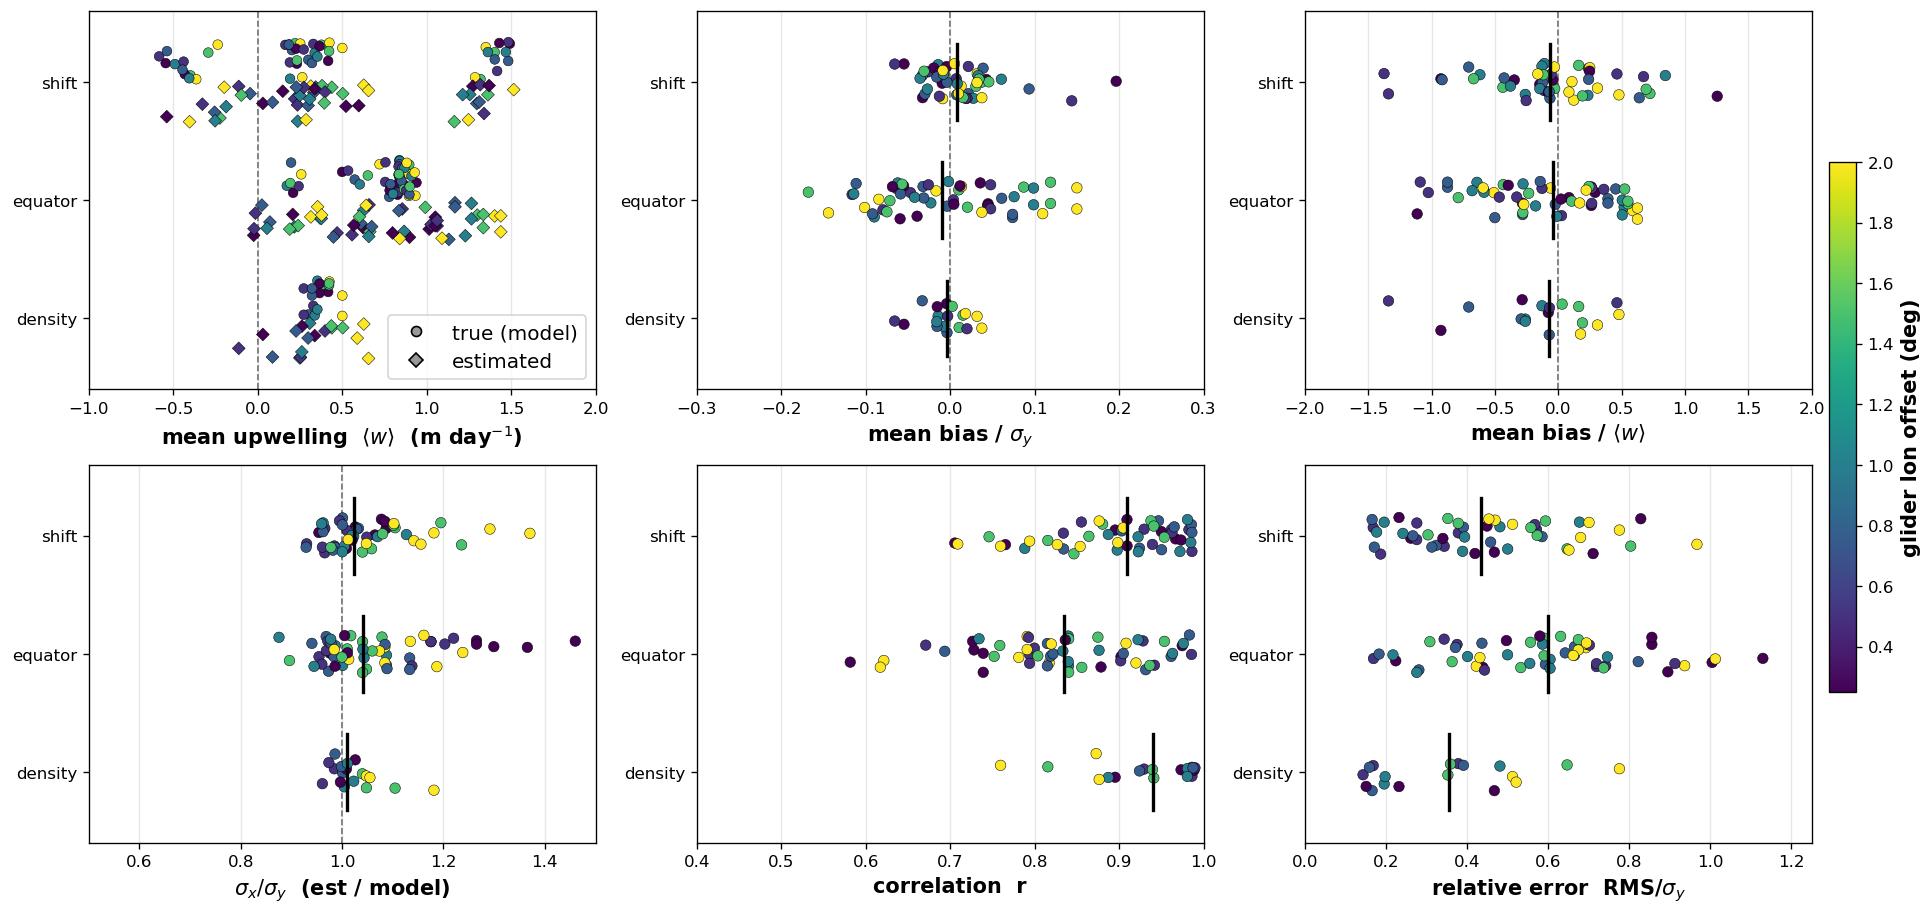

In [2]:
sft.make_fig1(m, SUMDIR)

## Figure 2 - skill vs array width

One line per (method, estimate location). **Color = where the estimate is
centered** (`center_lat`), so estimates at the same latitude share a color;
**linestyle + marker = method** (the sampling pattern). This disaggregates the
multi-cell arrays, which the earlier one-line-per-pattern version hid by
averaging over cells at different latitudes.

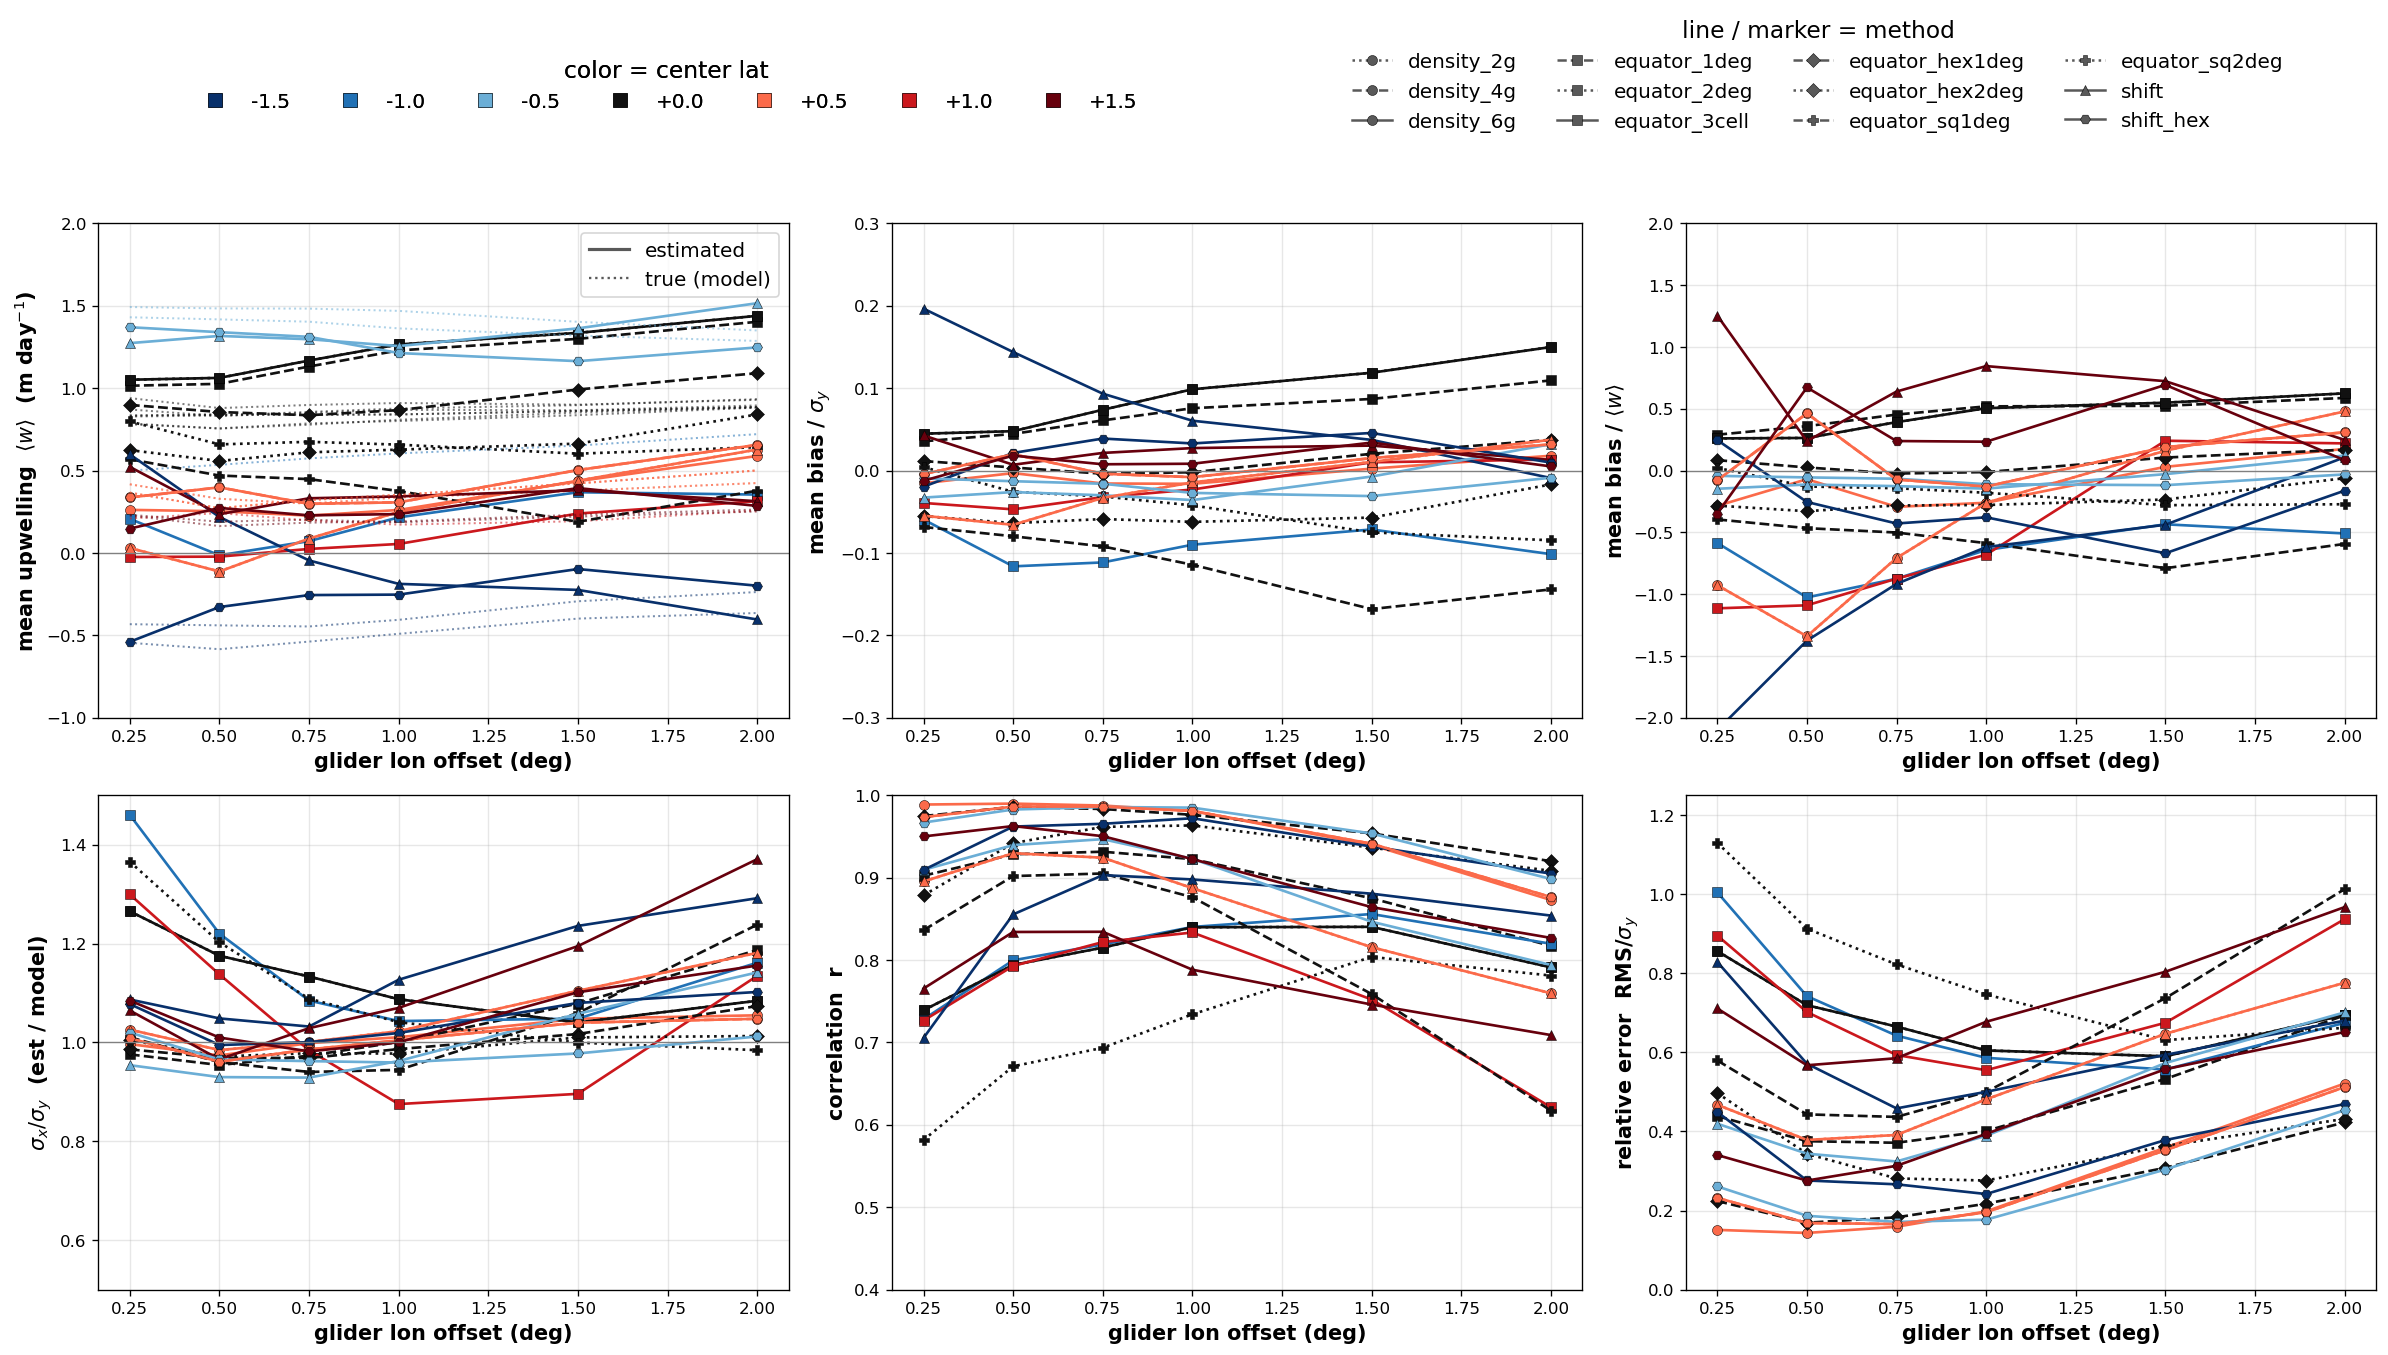

In [3]:
sft.make_fig2_combined(m, SUMDIR)

## Figures 2a-2d - skill vs width, one method at a time

Per-method breakdown of the combined Figure 2, so each is readable. x = glider
lon offset throughout; each figure colors its lines by whatever is tuned within
that method (never by width), and carries a fourth panel with the platform layout
(squares = moorings, circles = gliders; offset drawn = 0.5°).

- **2a shift array** - one 4-cell array; color = cell center latitude
  (−1.5, −0.5, +0.5, +1.5). Layout stacked: the four 1°-tall cells tile lat −2→+2.
- **2b equator 3-cell** - color = cell center latitude (−1 / 0 / +1). Layout
  stacked: three 2°-tall cells sharing the −2…+2 moorings, each now using its
  interior center mooring.
- **2c density** - center fixed at +0.5, color = gliders-per-cell; layout shows
  the 2/4/6-glider alternatives side by side.
- **2d equator single-cell** - center fixed at 0.0. Compares **diamond vs hexagon**
  at **1° vs 2° tall**: color = height (1° blue / 2° red), line/marker = shape
  (solid ◇ diamond, dashed ◈ hexagon). The hexagon adds mid-latitude side gliders
  (1° tall → 6 gliders, 2° tall → 4 gliders since its ±1° N/S sit on moorings).

Every cell also uses any interior mooring (the equator cells' center mooring,
the 3-cell cells' center moorings) — see generate_configs `_interior_moorings`.

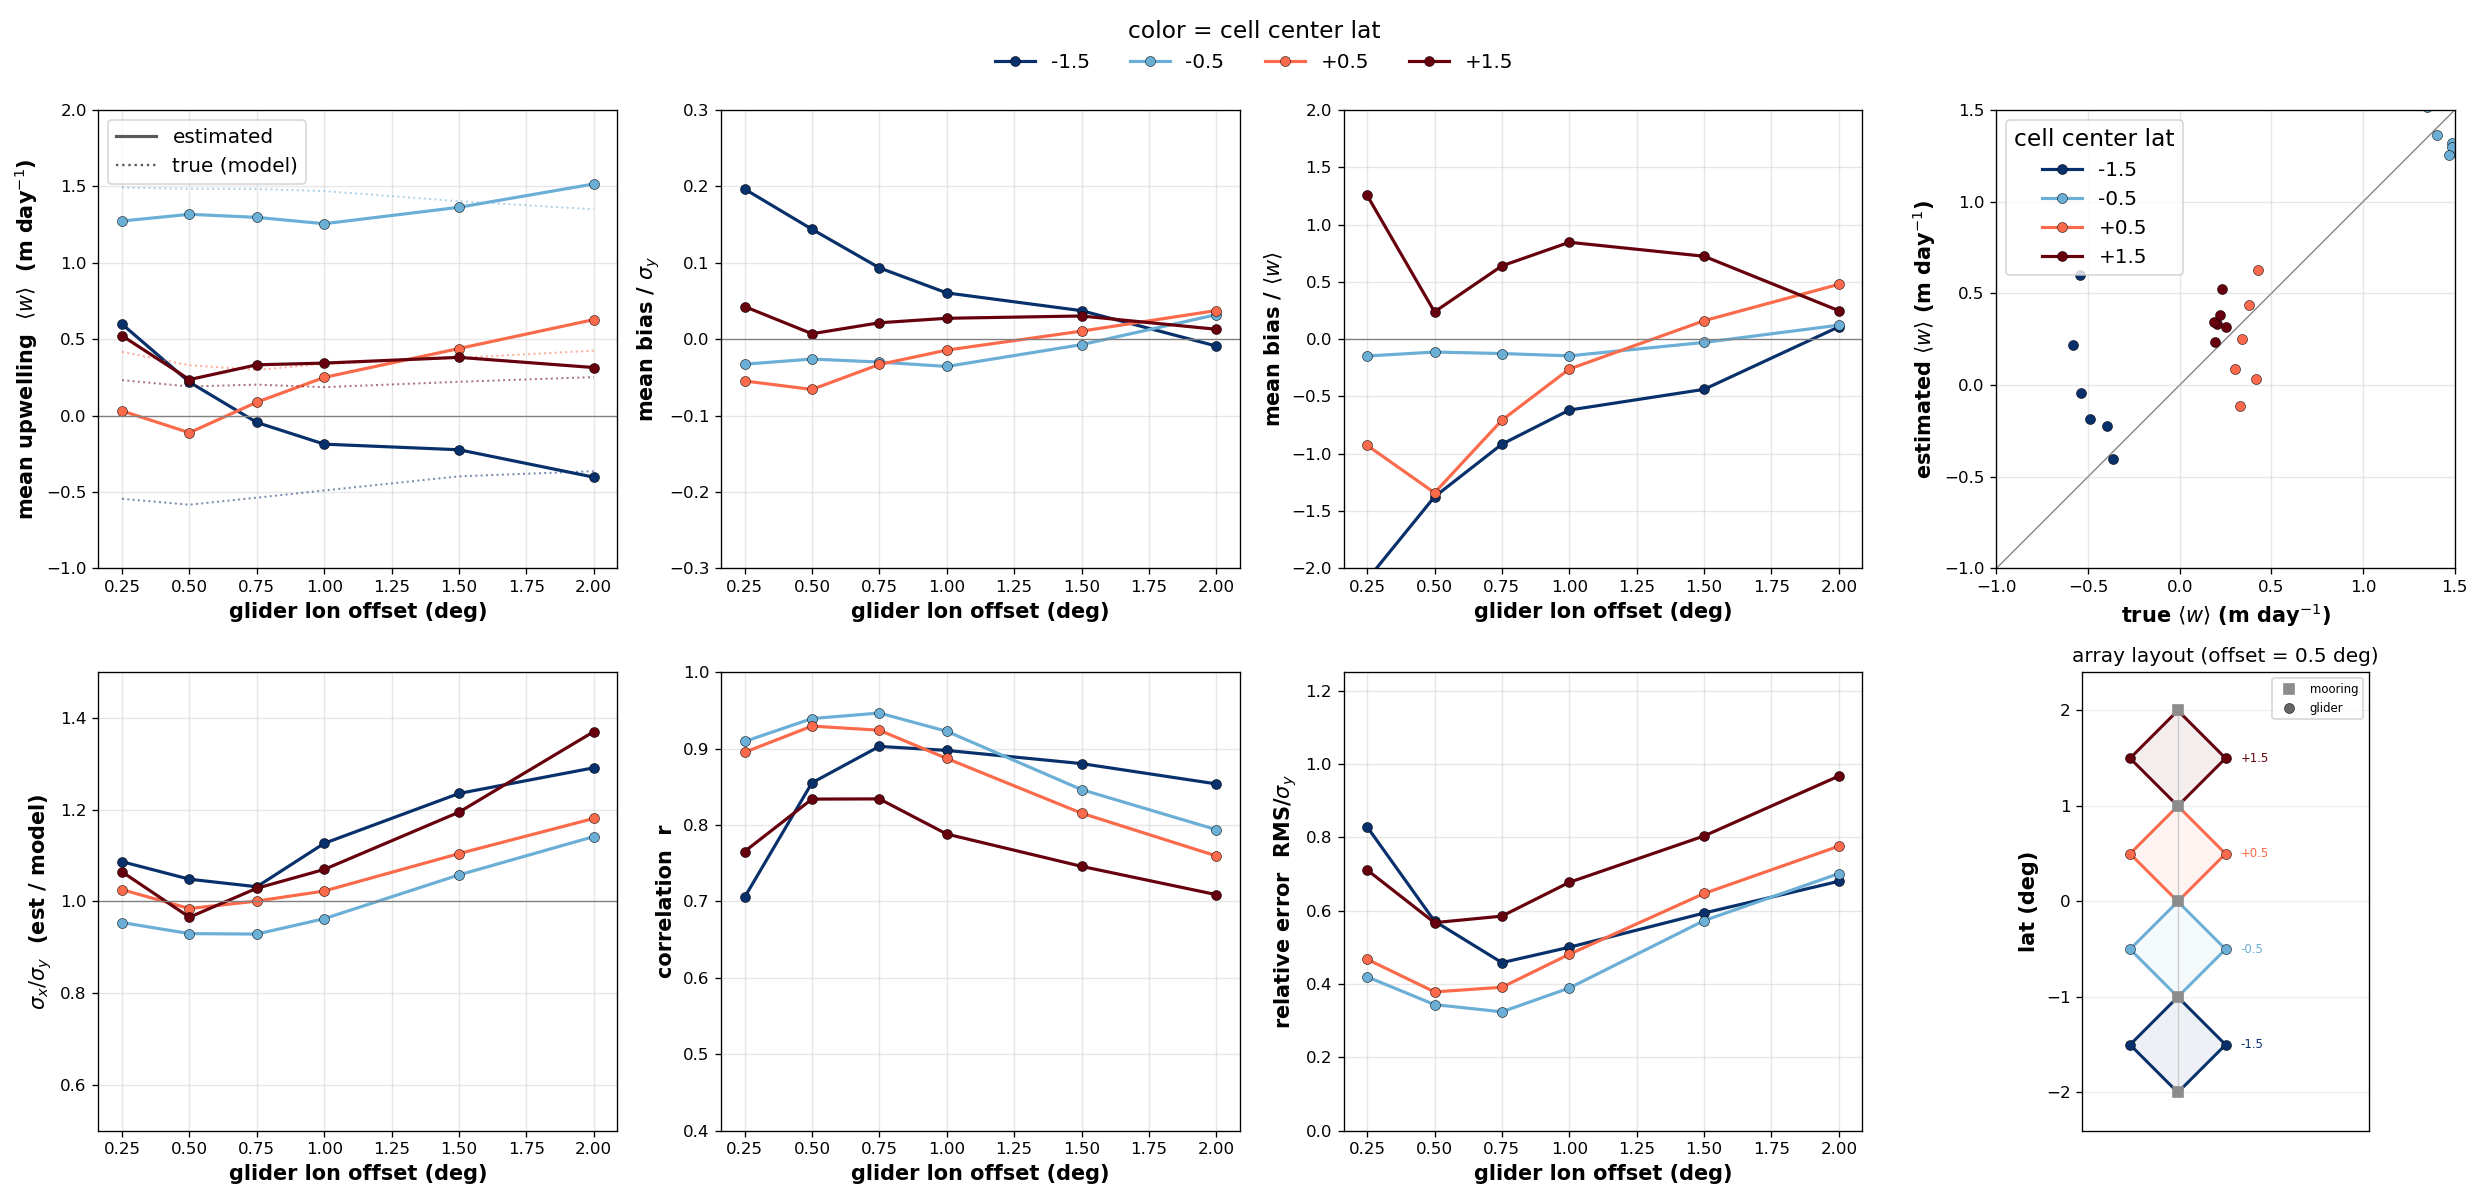

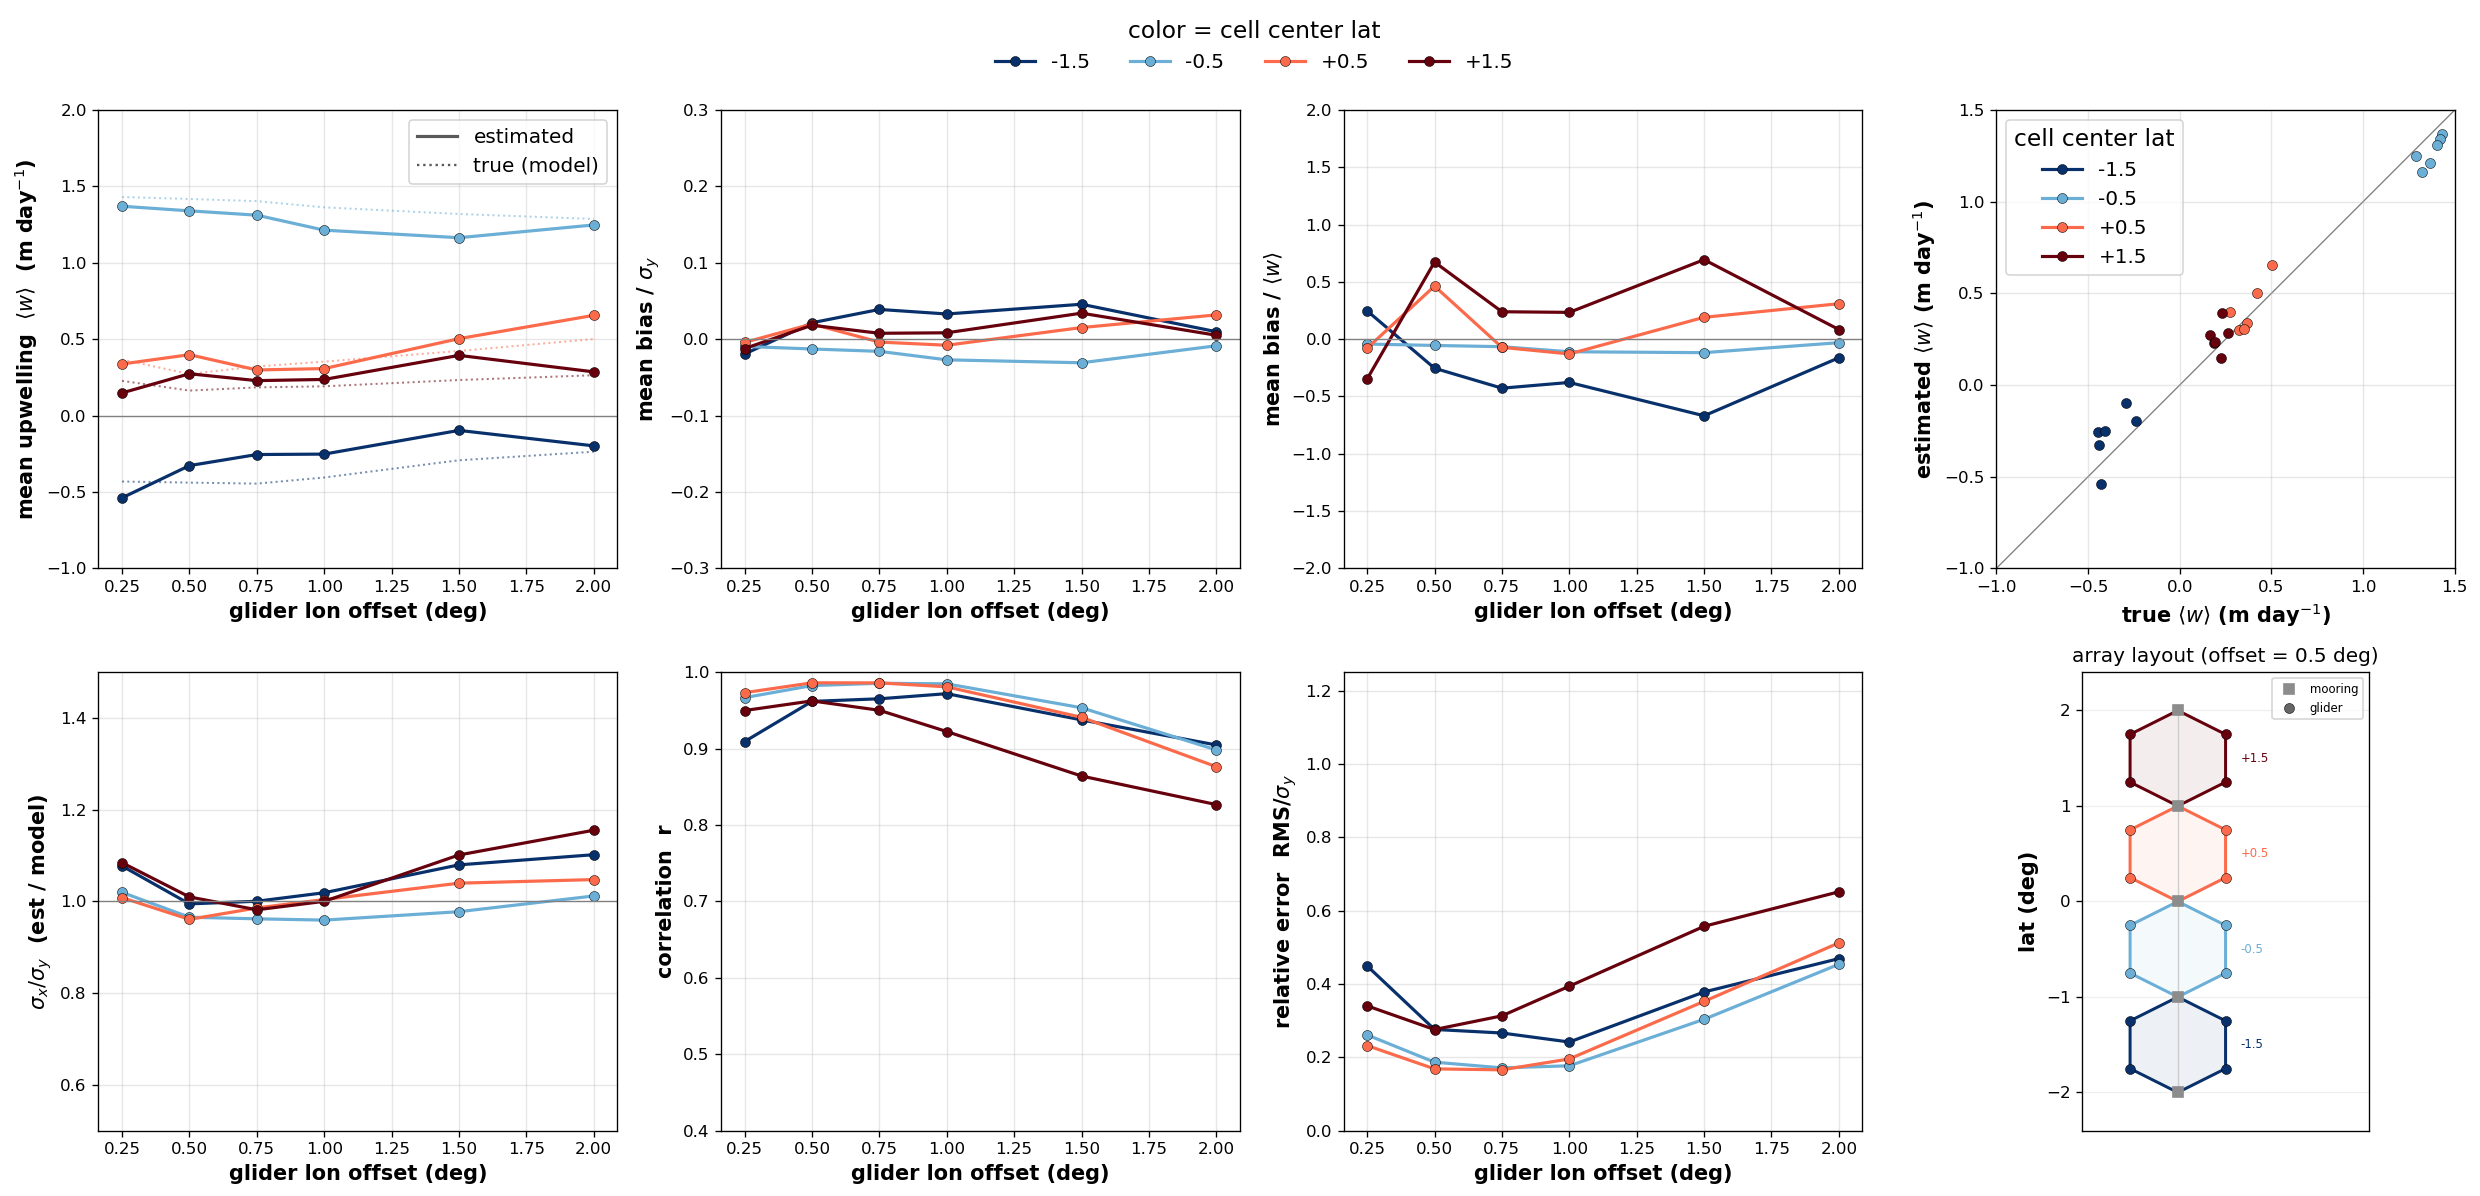

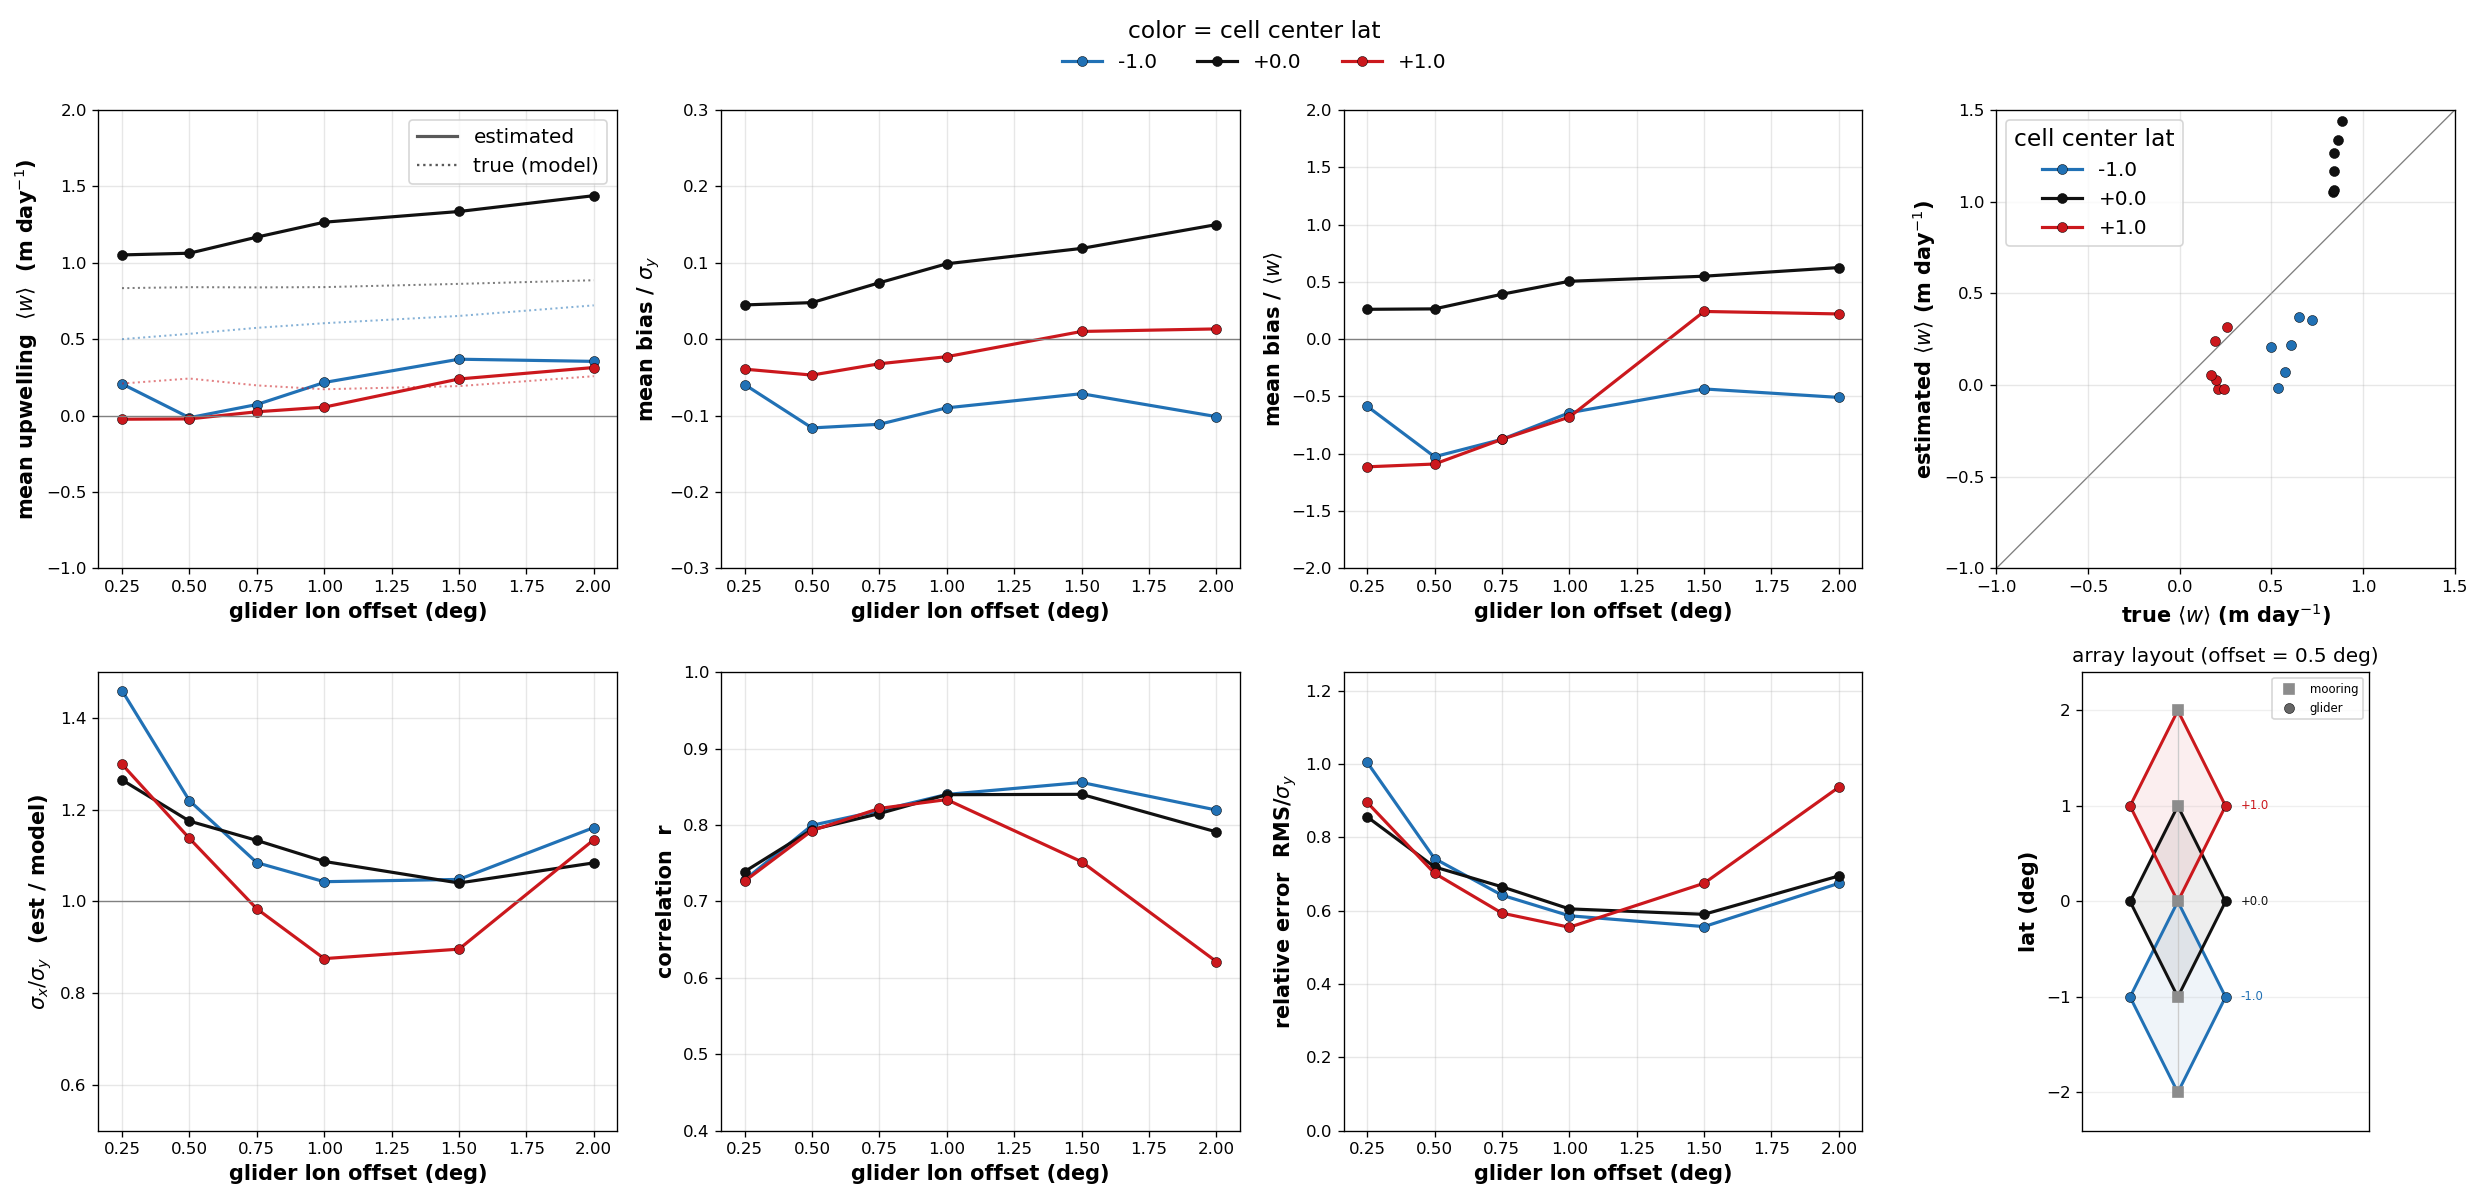

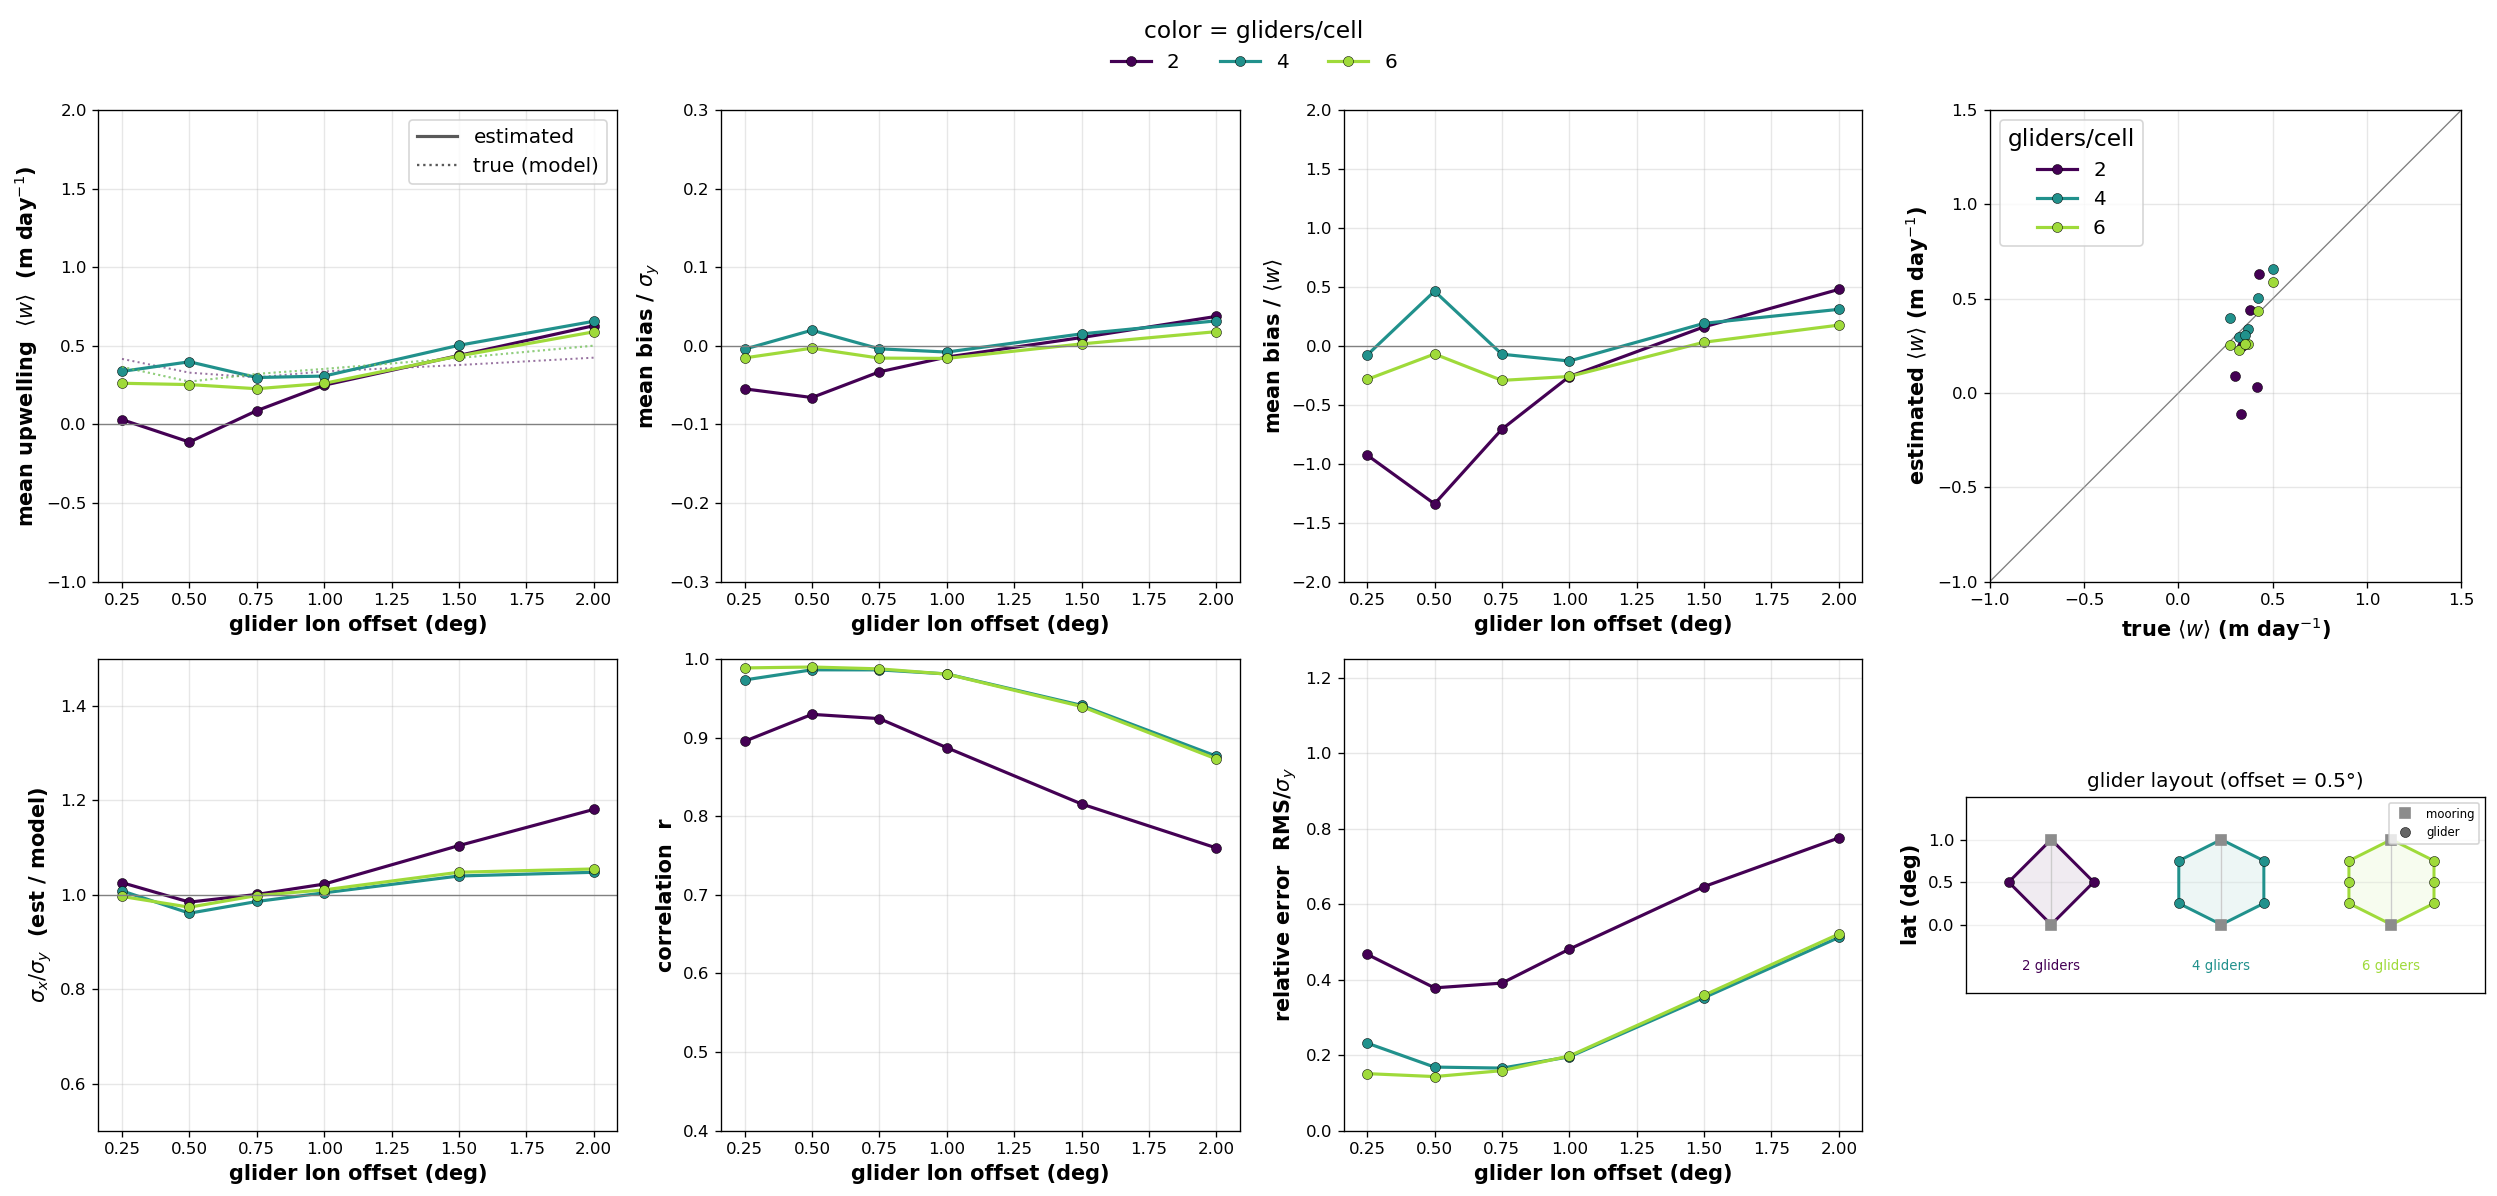

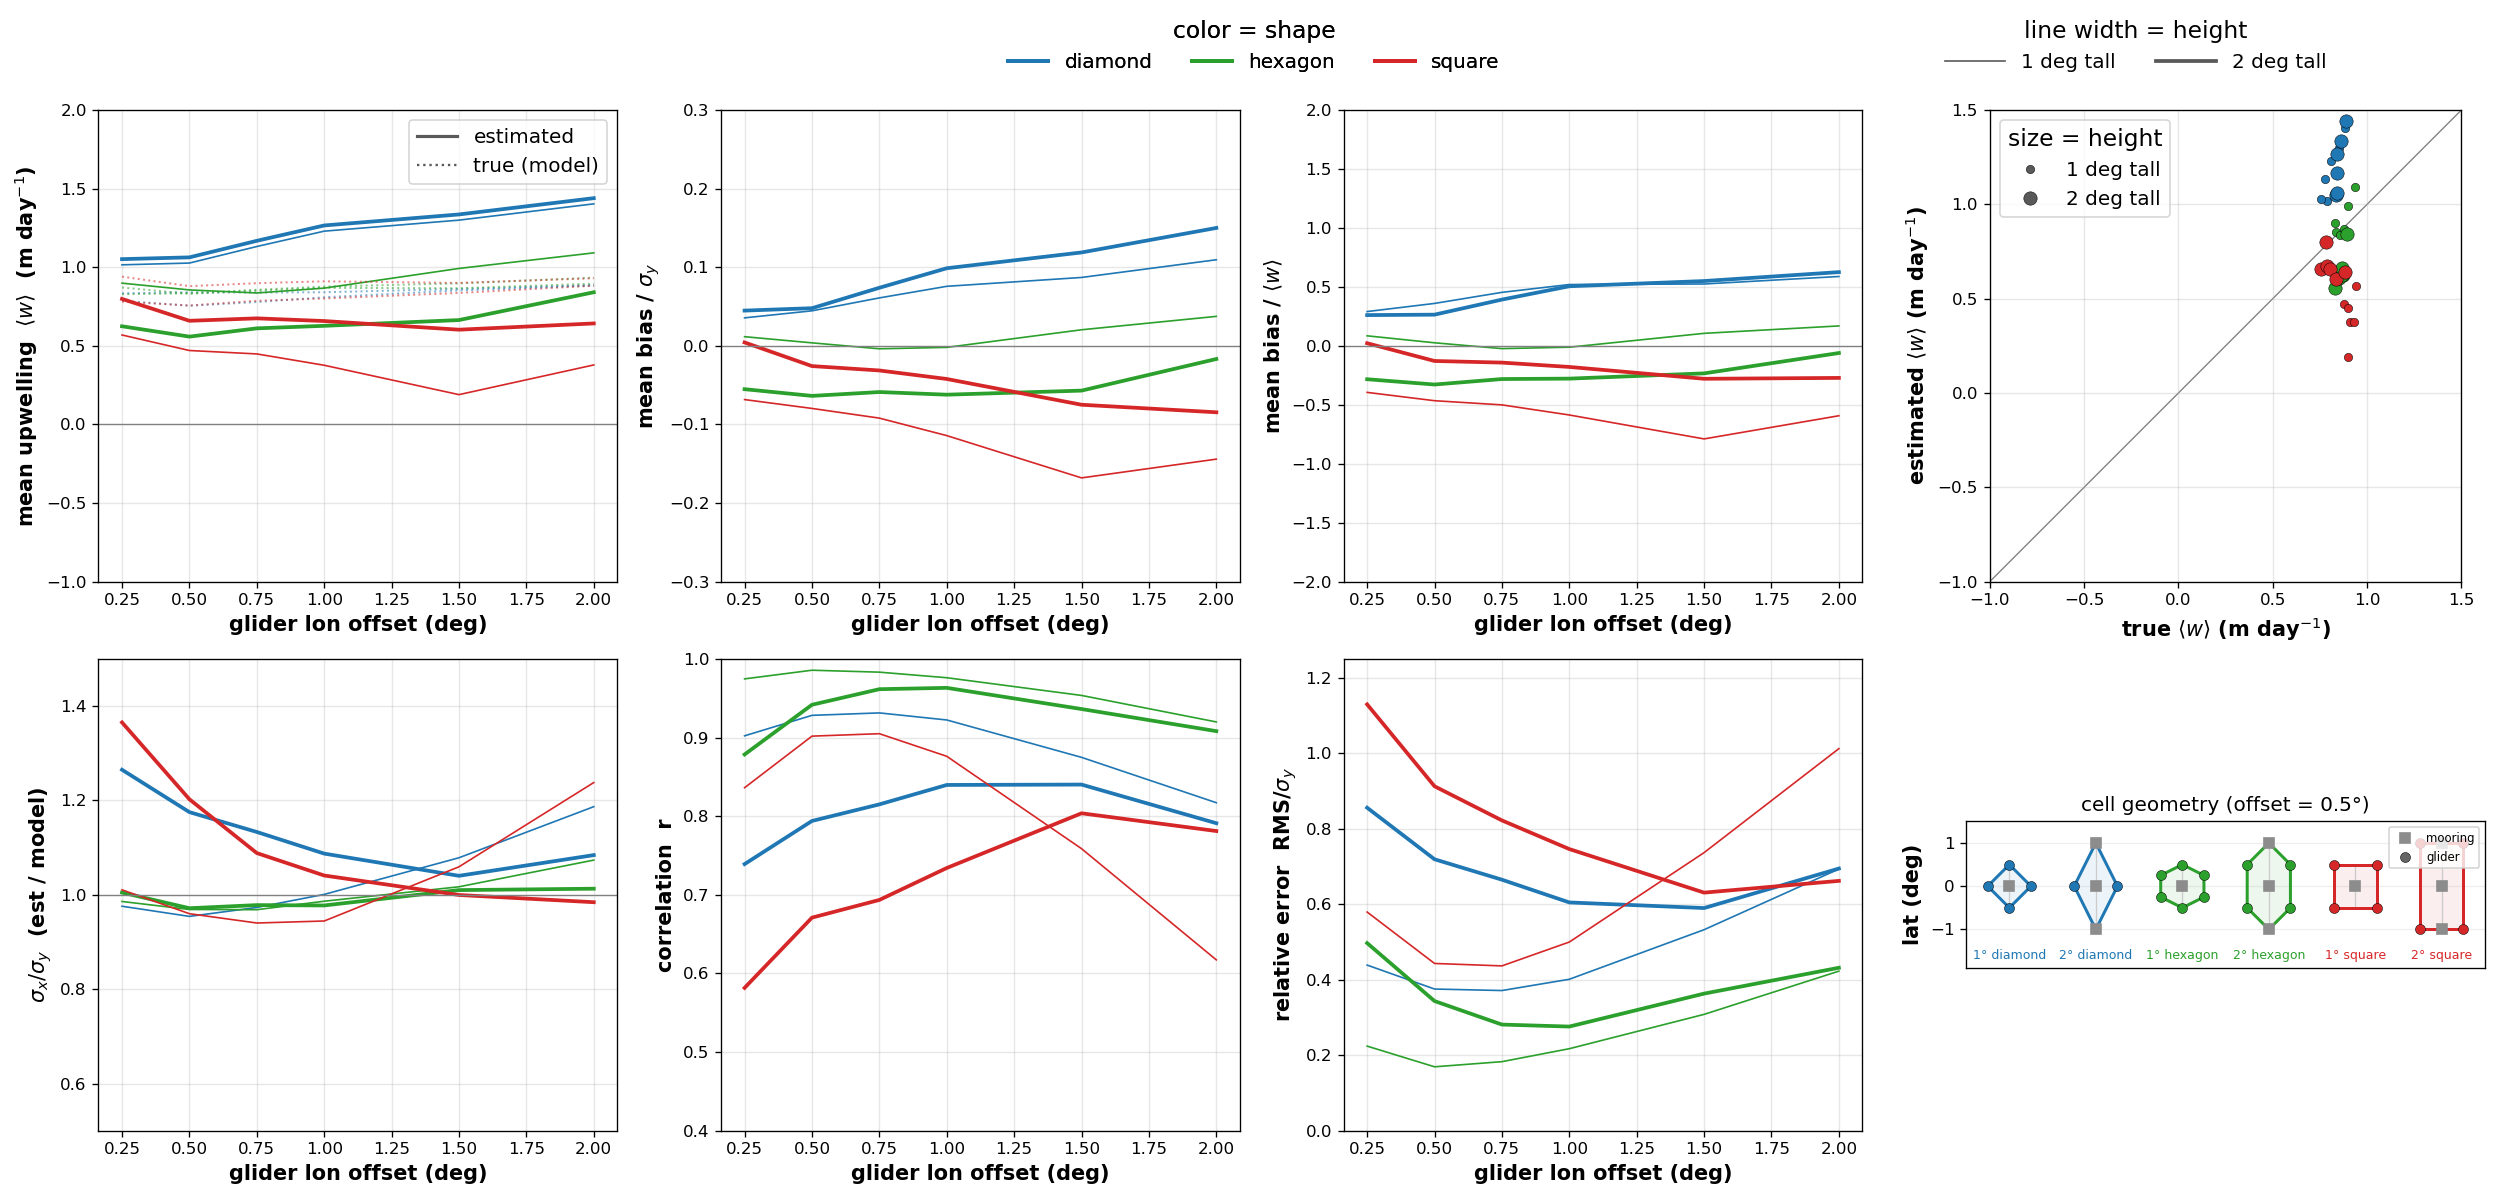

In [4]:
sft.make_fig2abcd(m, SUMDIR)

## Figure 3 - skill vs cell latitude

The two arrays whose cells sit at different latitudes — the 4-cell shift array
and the equator 3-cell array — with one line per glider offset. (The old
separate north/south panels are combined into the single 4-cell shift array.)

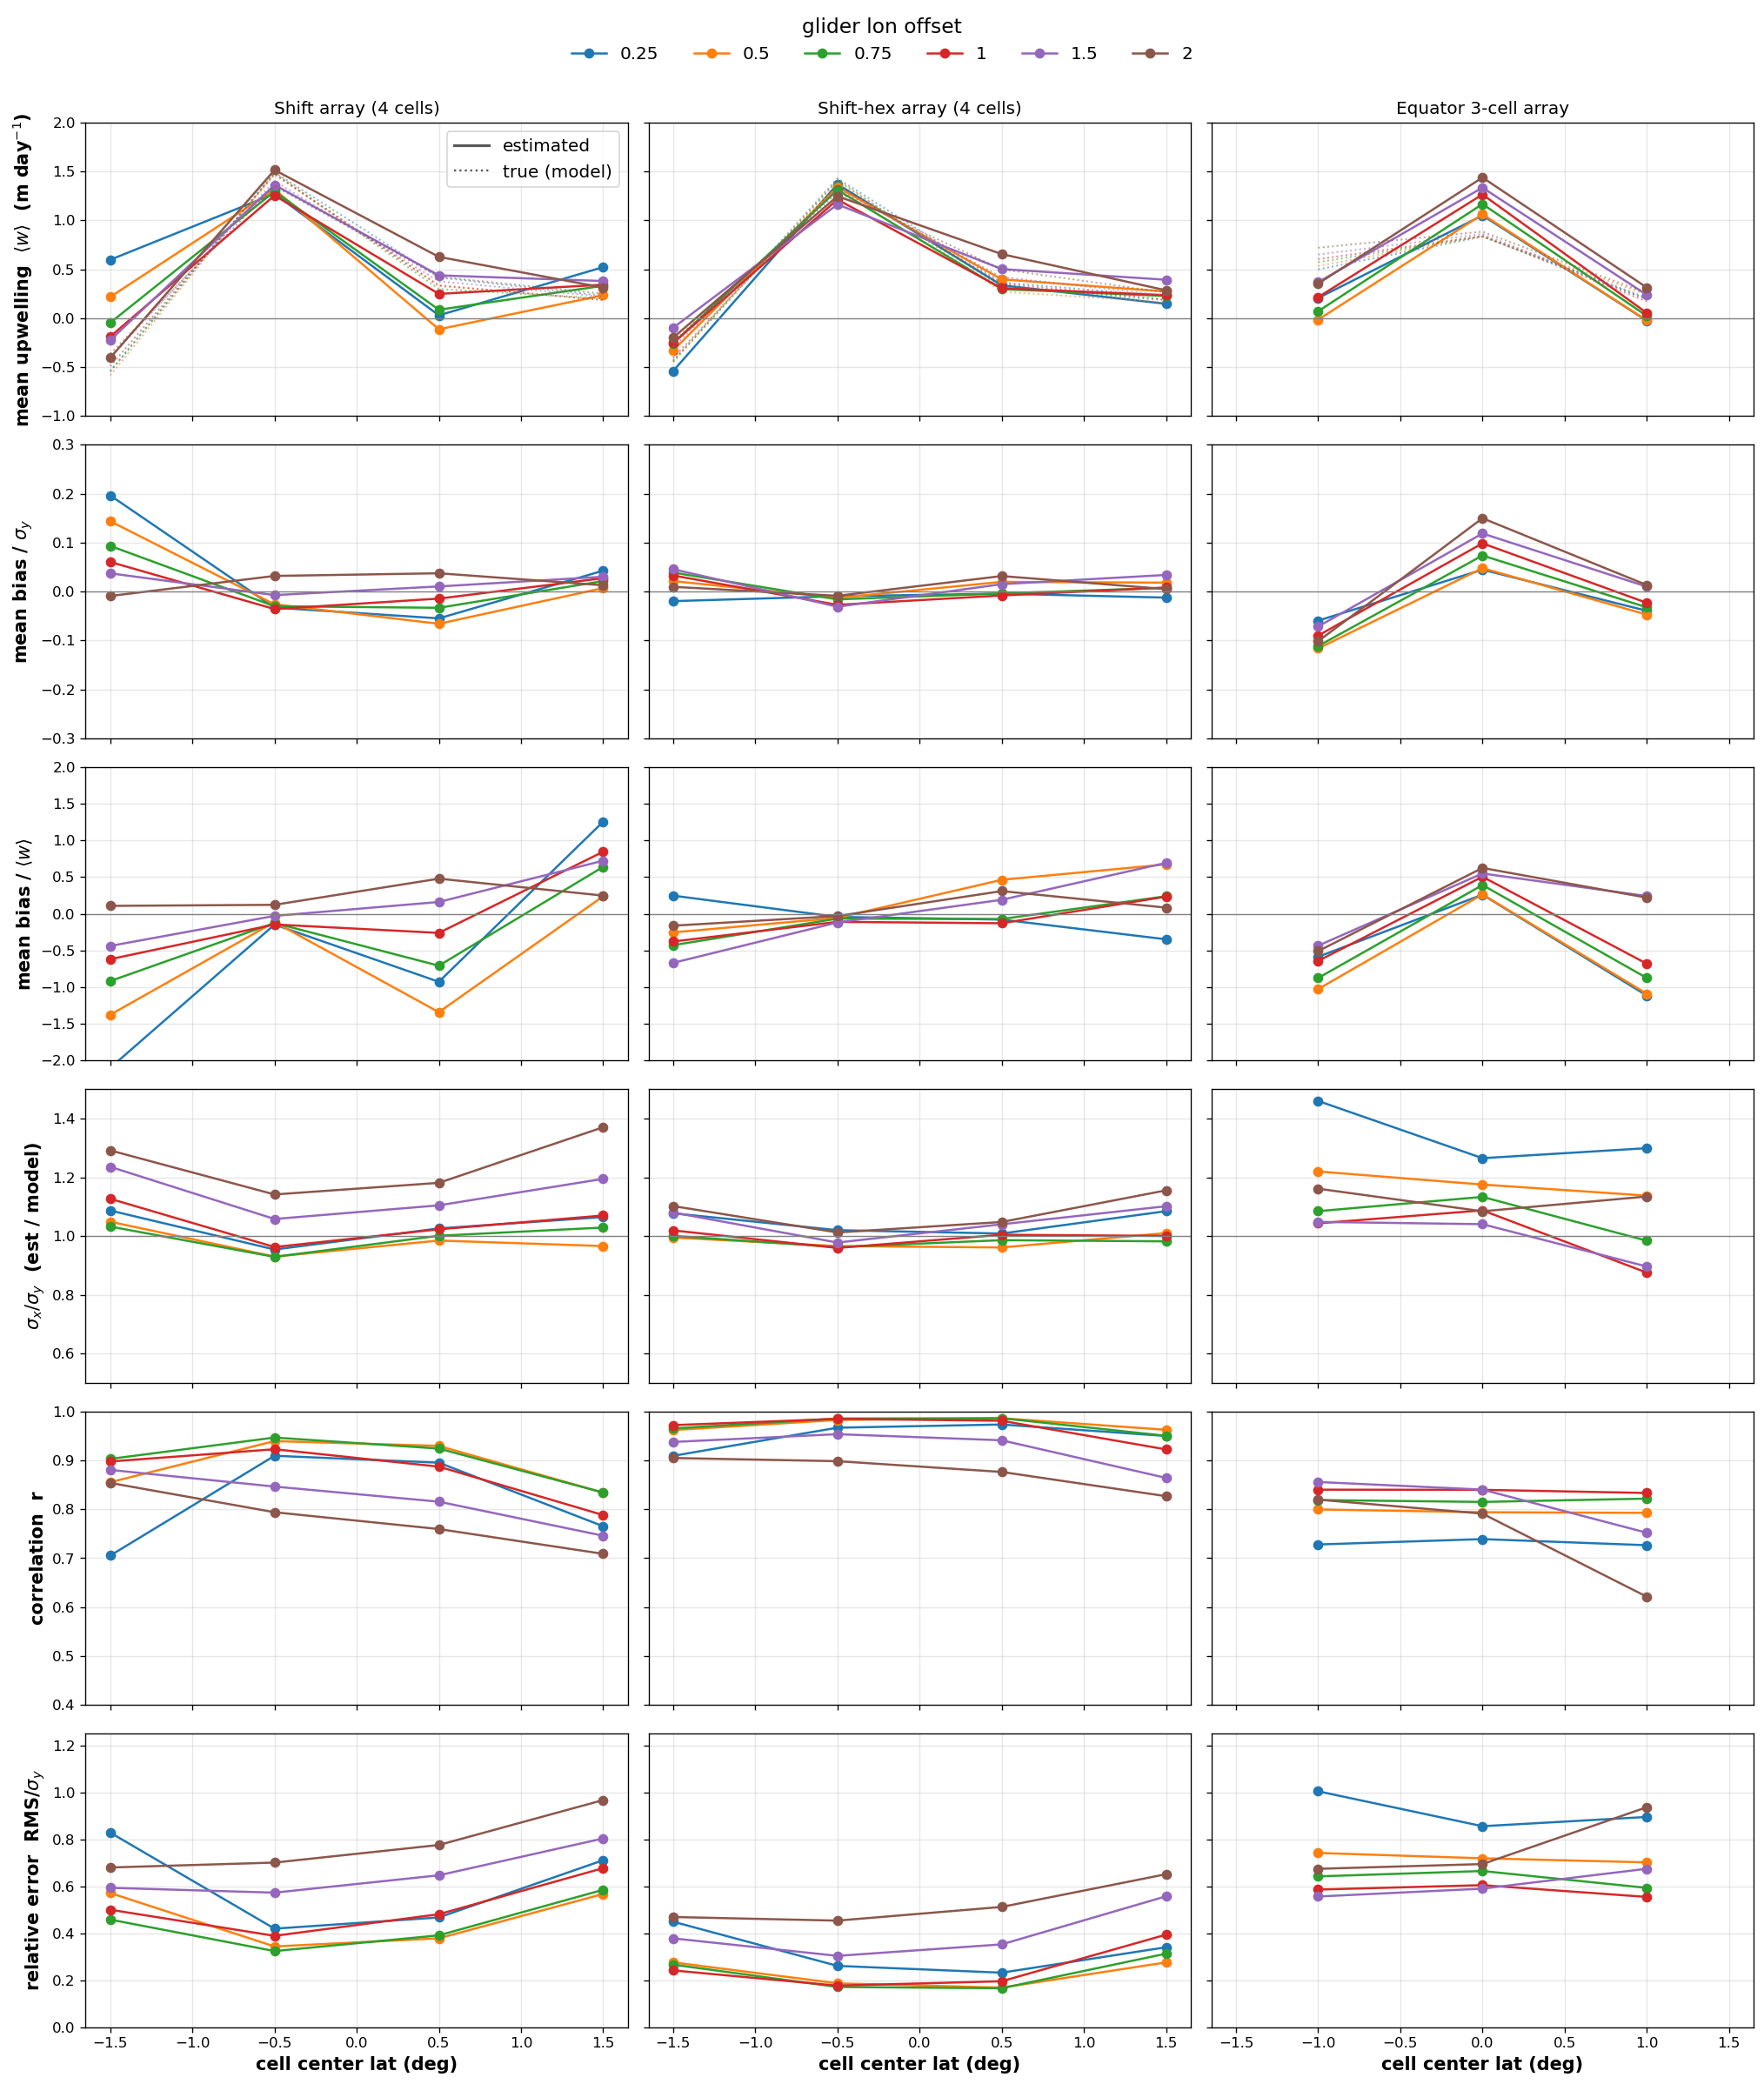

In [5]:
sft.make_fig3(m, SUMDIR)

## Figure 4 - skill vs gliders-per-cell

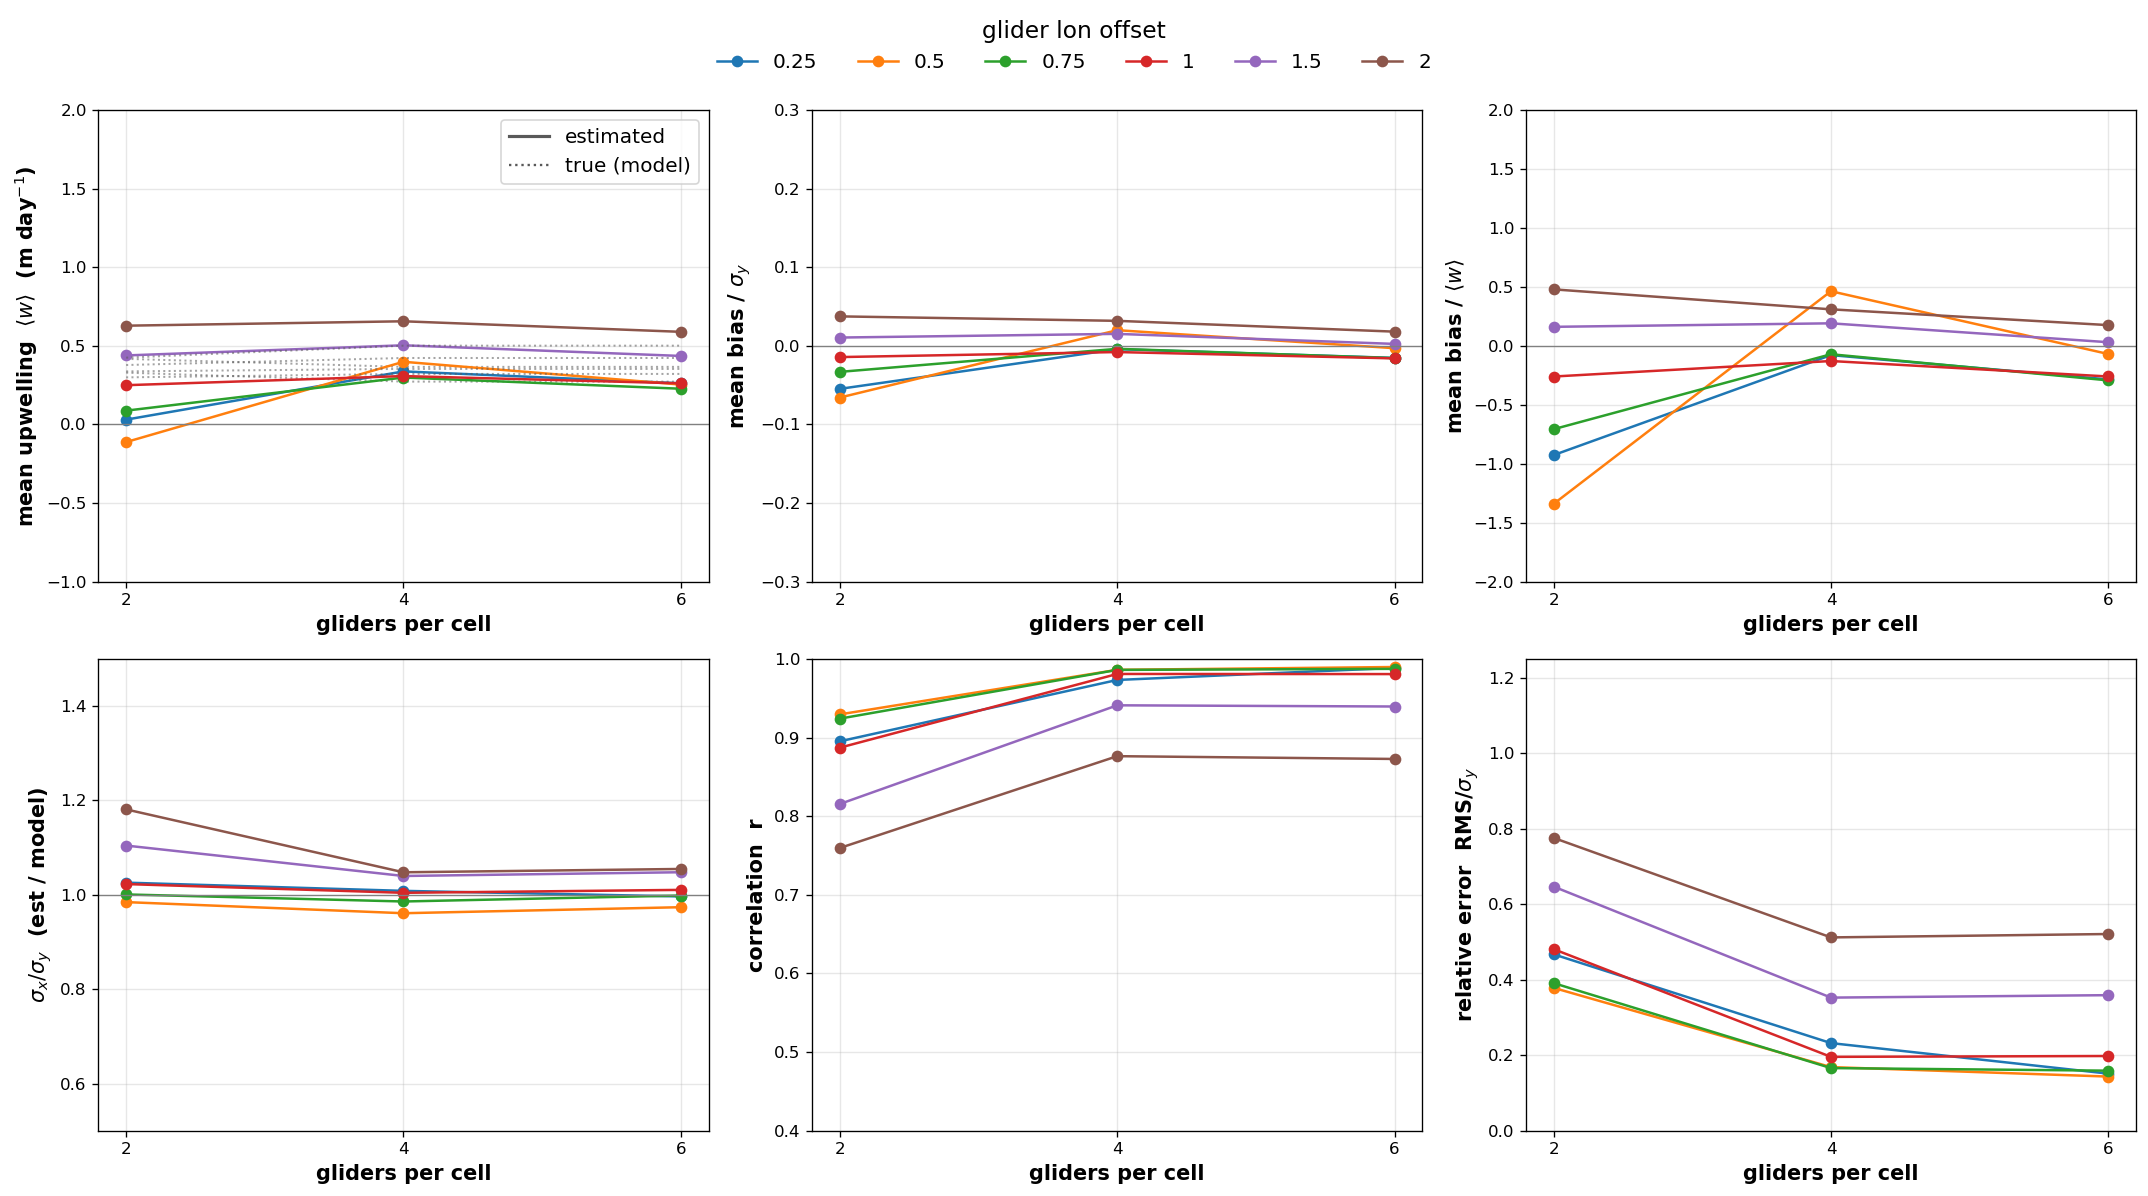

In [6]:
sft.make_fig4(m, SUMDIR)

## Figures 5a-5d - skill vs depth, within each method

Depth-resolved skill at a fixed glider offset (`DEPTH_WIDTH = 1.0°` for 5a-5c,
`0.5°` for 5d), one figure per method, colored by the same within-method knob
as 2a-2d — so this evaluates the tunable parameters inside a method, not a
comparison between methods. Panels: normalized error, correlation, fractional
mean bias (⟨w_est⟩−⟨w_model⟩)/⟨w_model⟩ (masked to NaN at the mean's
zero-crossings, where it is undefined), absolute RMS (solid) vs signal std
(dotted), and the mean w profile itself — estimate (solid) vs model truth
(dotted).

- **5a shift** - lines = the 4 cell latitudes.
- **5b equator 3-cell** - lines = the 3 cell latitudes.
- **5c density** - lines = 2 / 4 / 6 gliders-per-cell.
- **5d equator single-cell** - diamond vs hexagon at 1° vs 2° tall, at glider
  offset 0.5° (color = height, line = shape).

Replaces the old single Figure 5, which averaged over each family's cells and so
hid the within-method dependence.

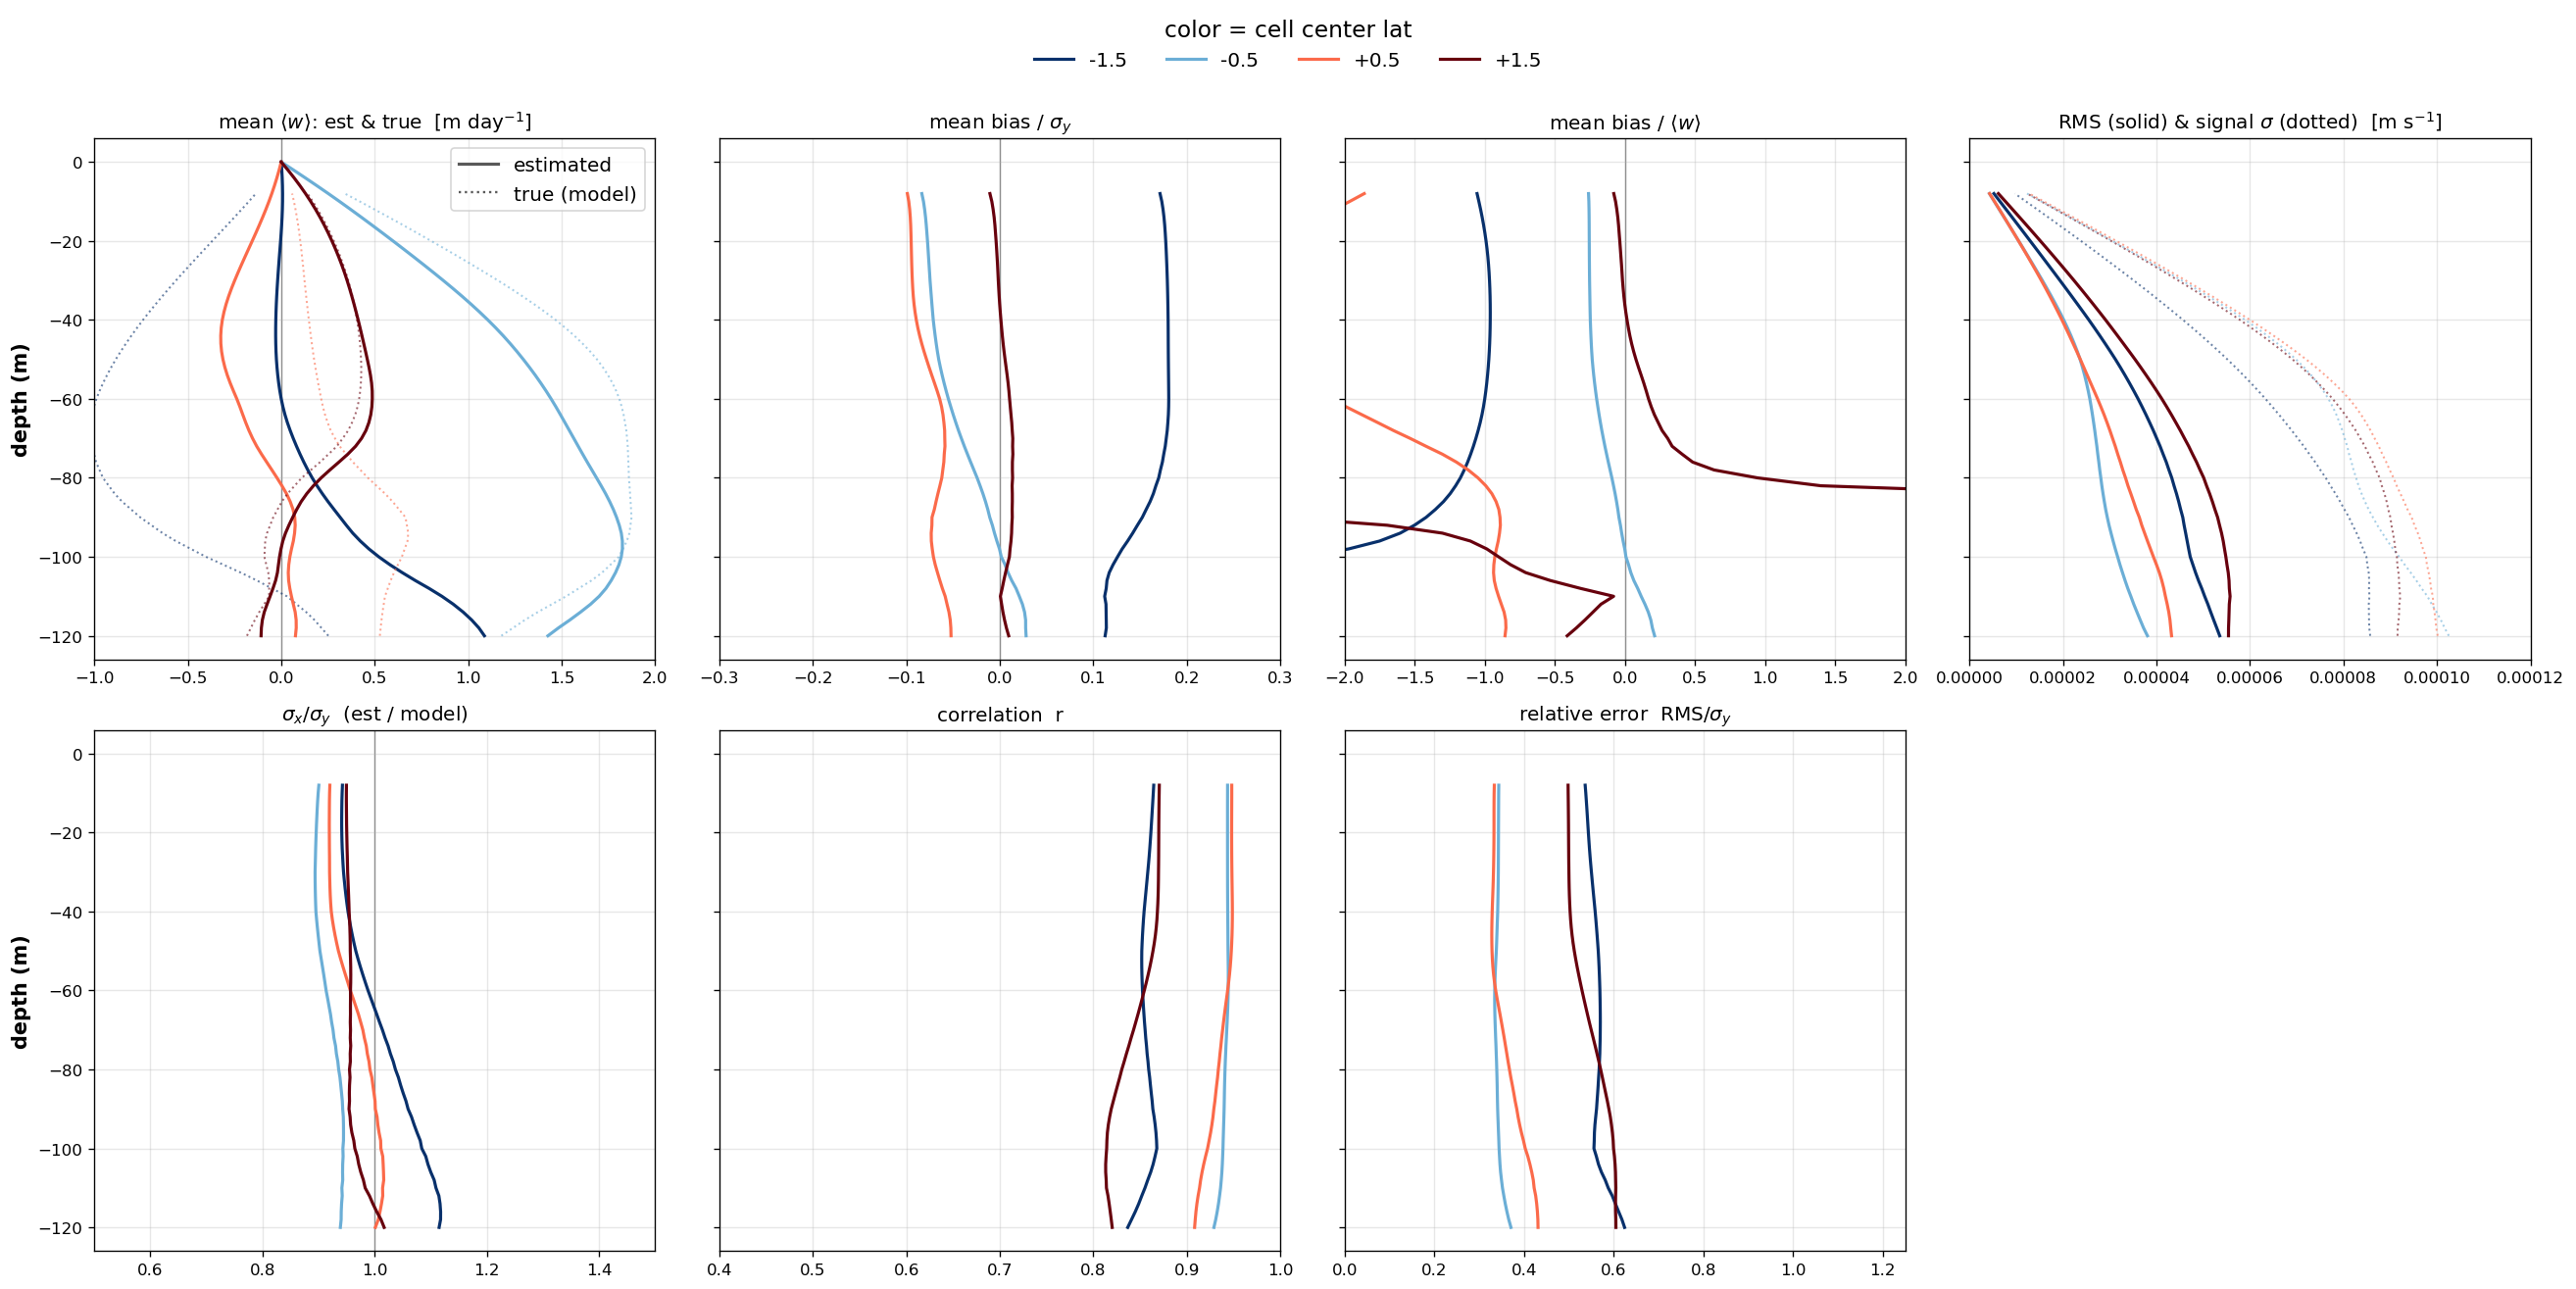

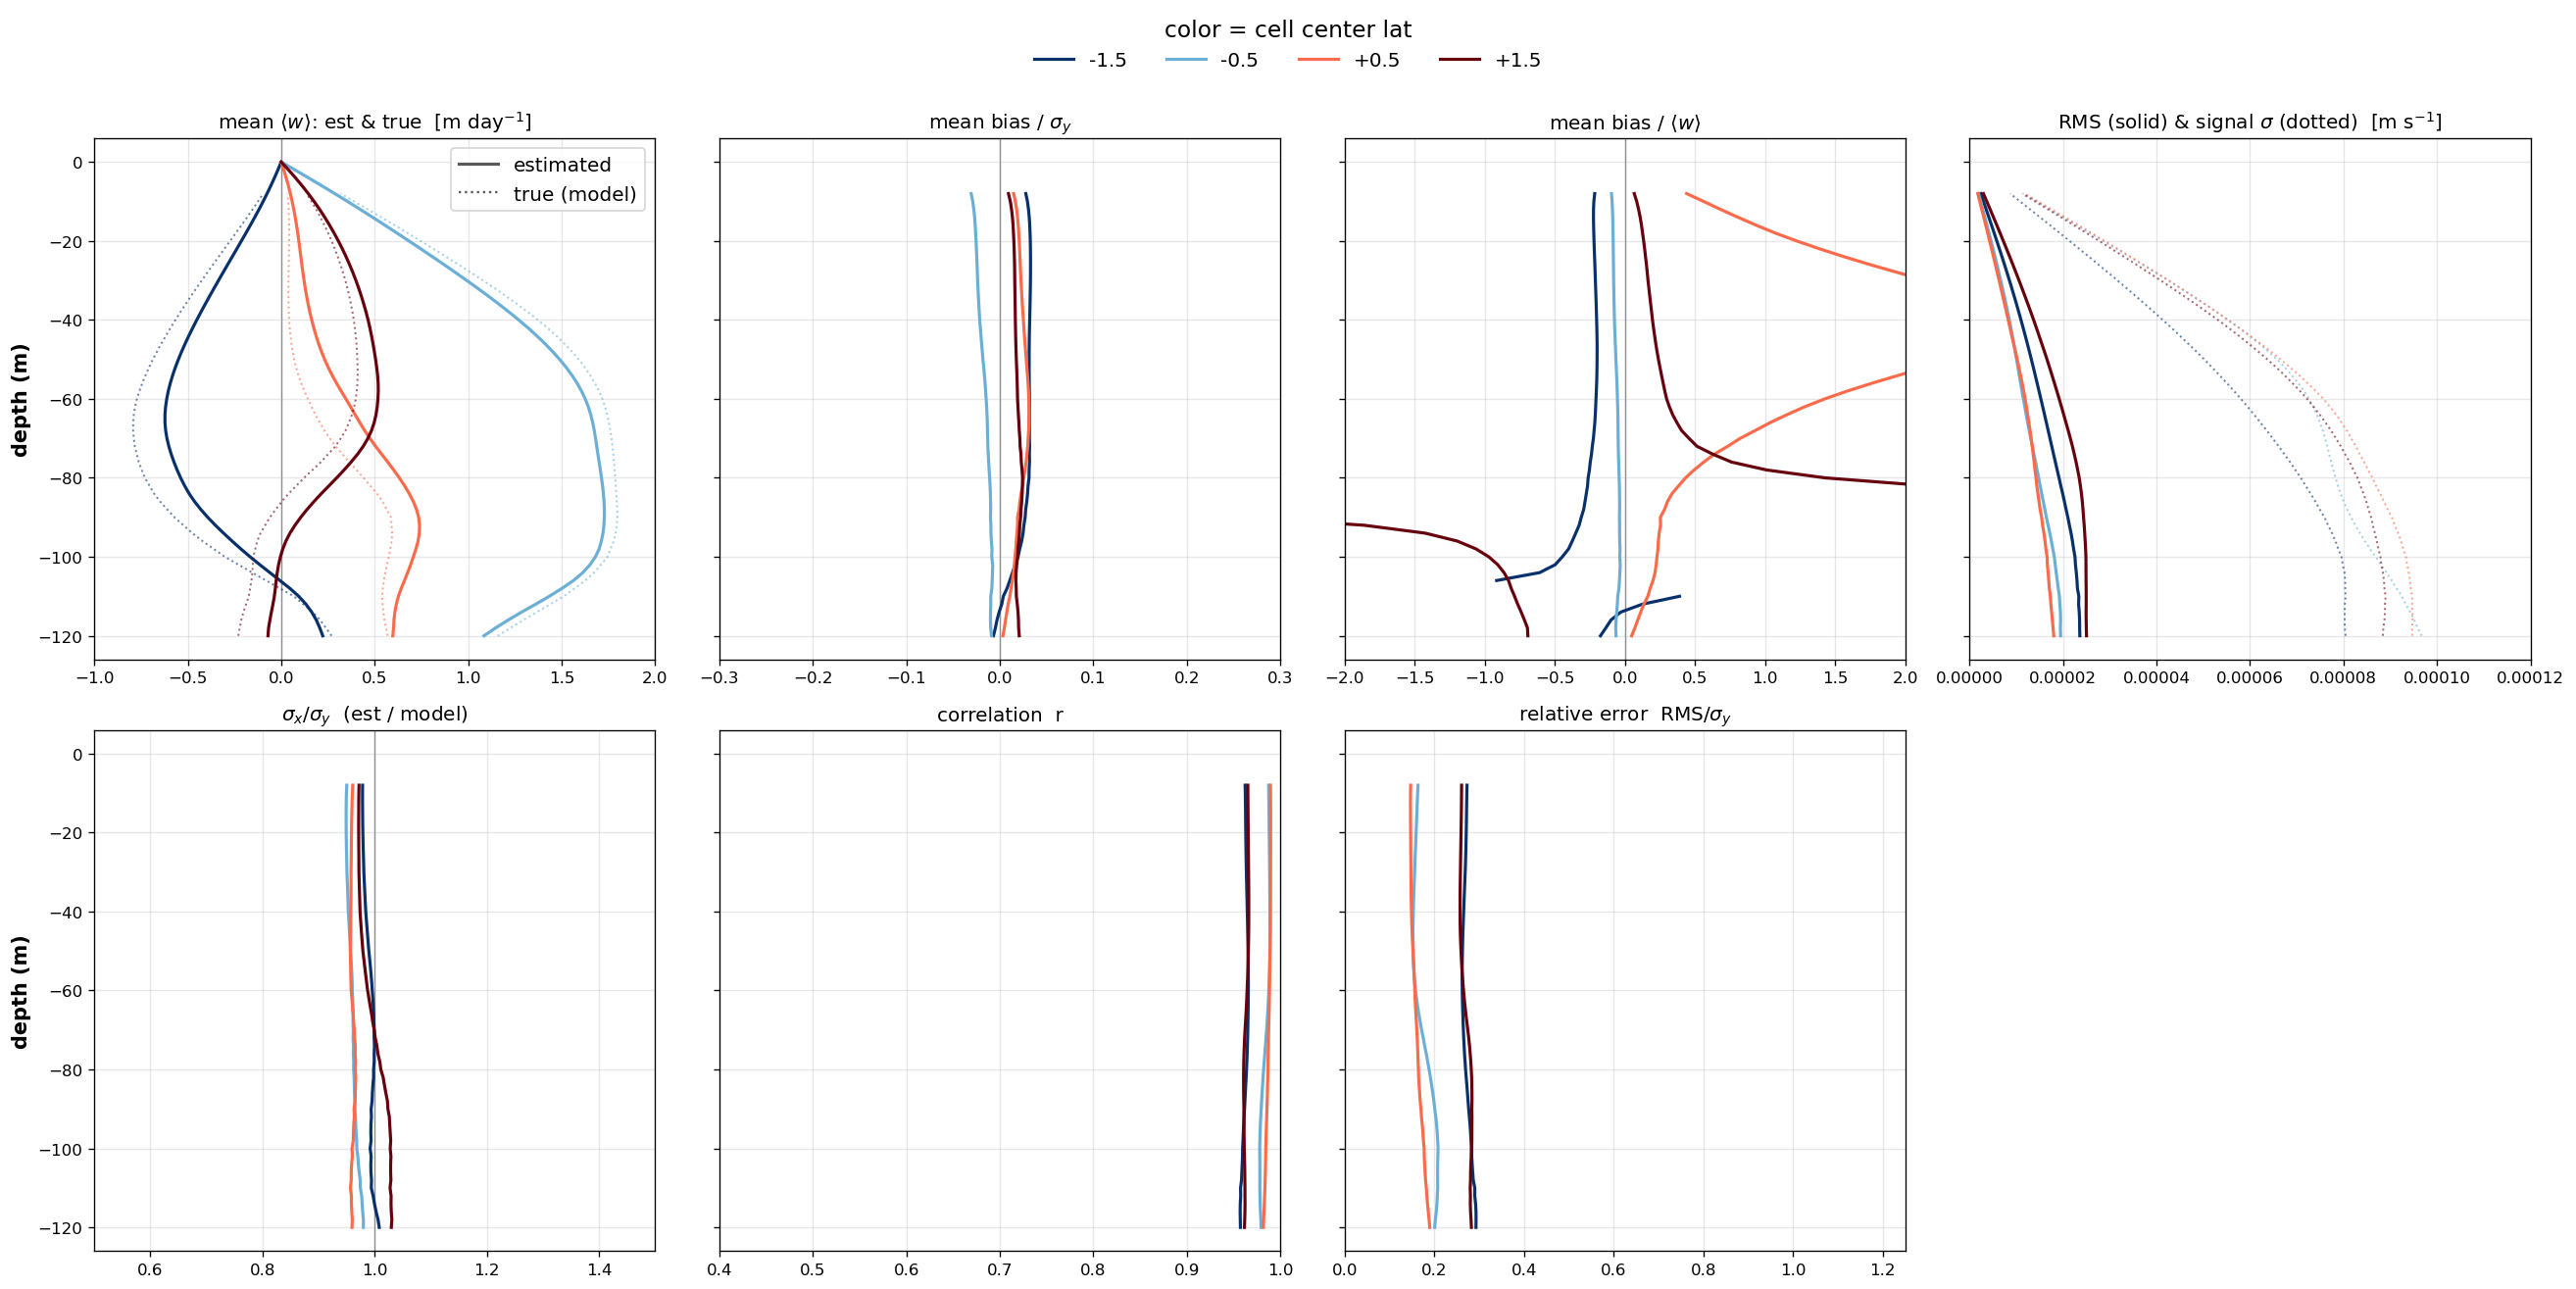

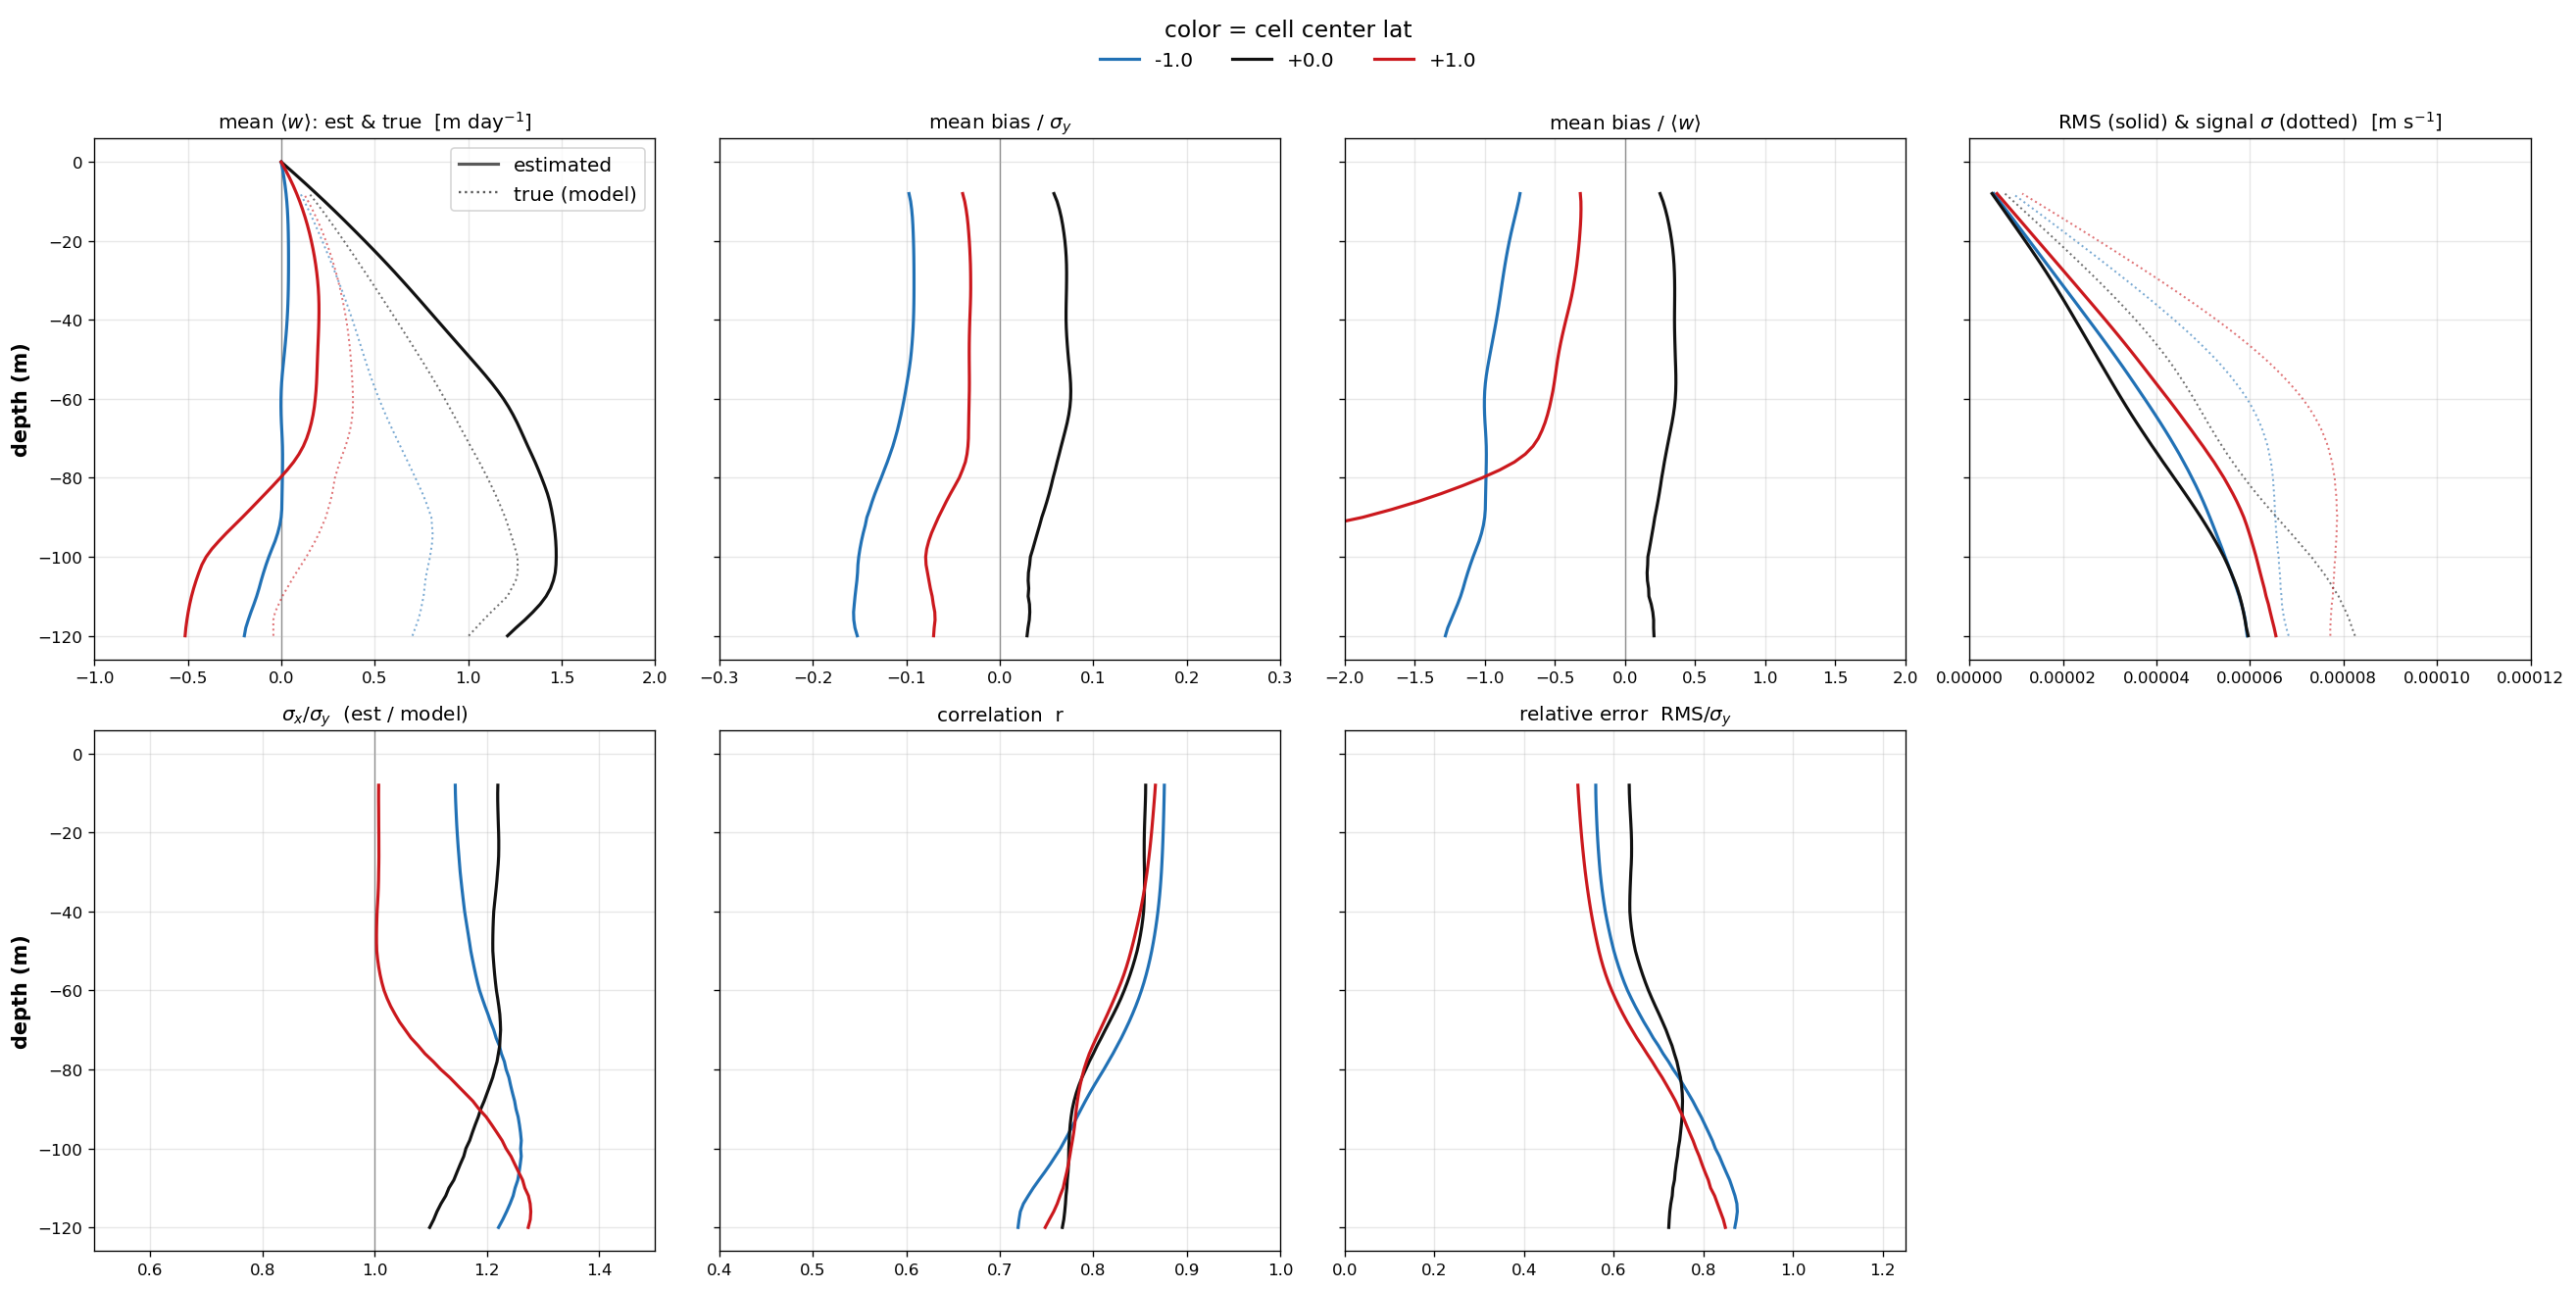

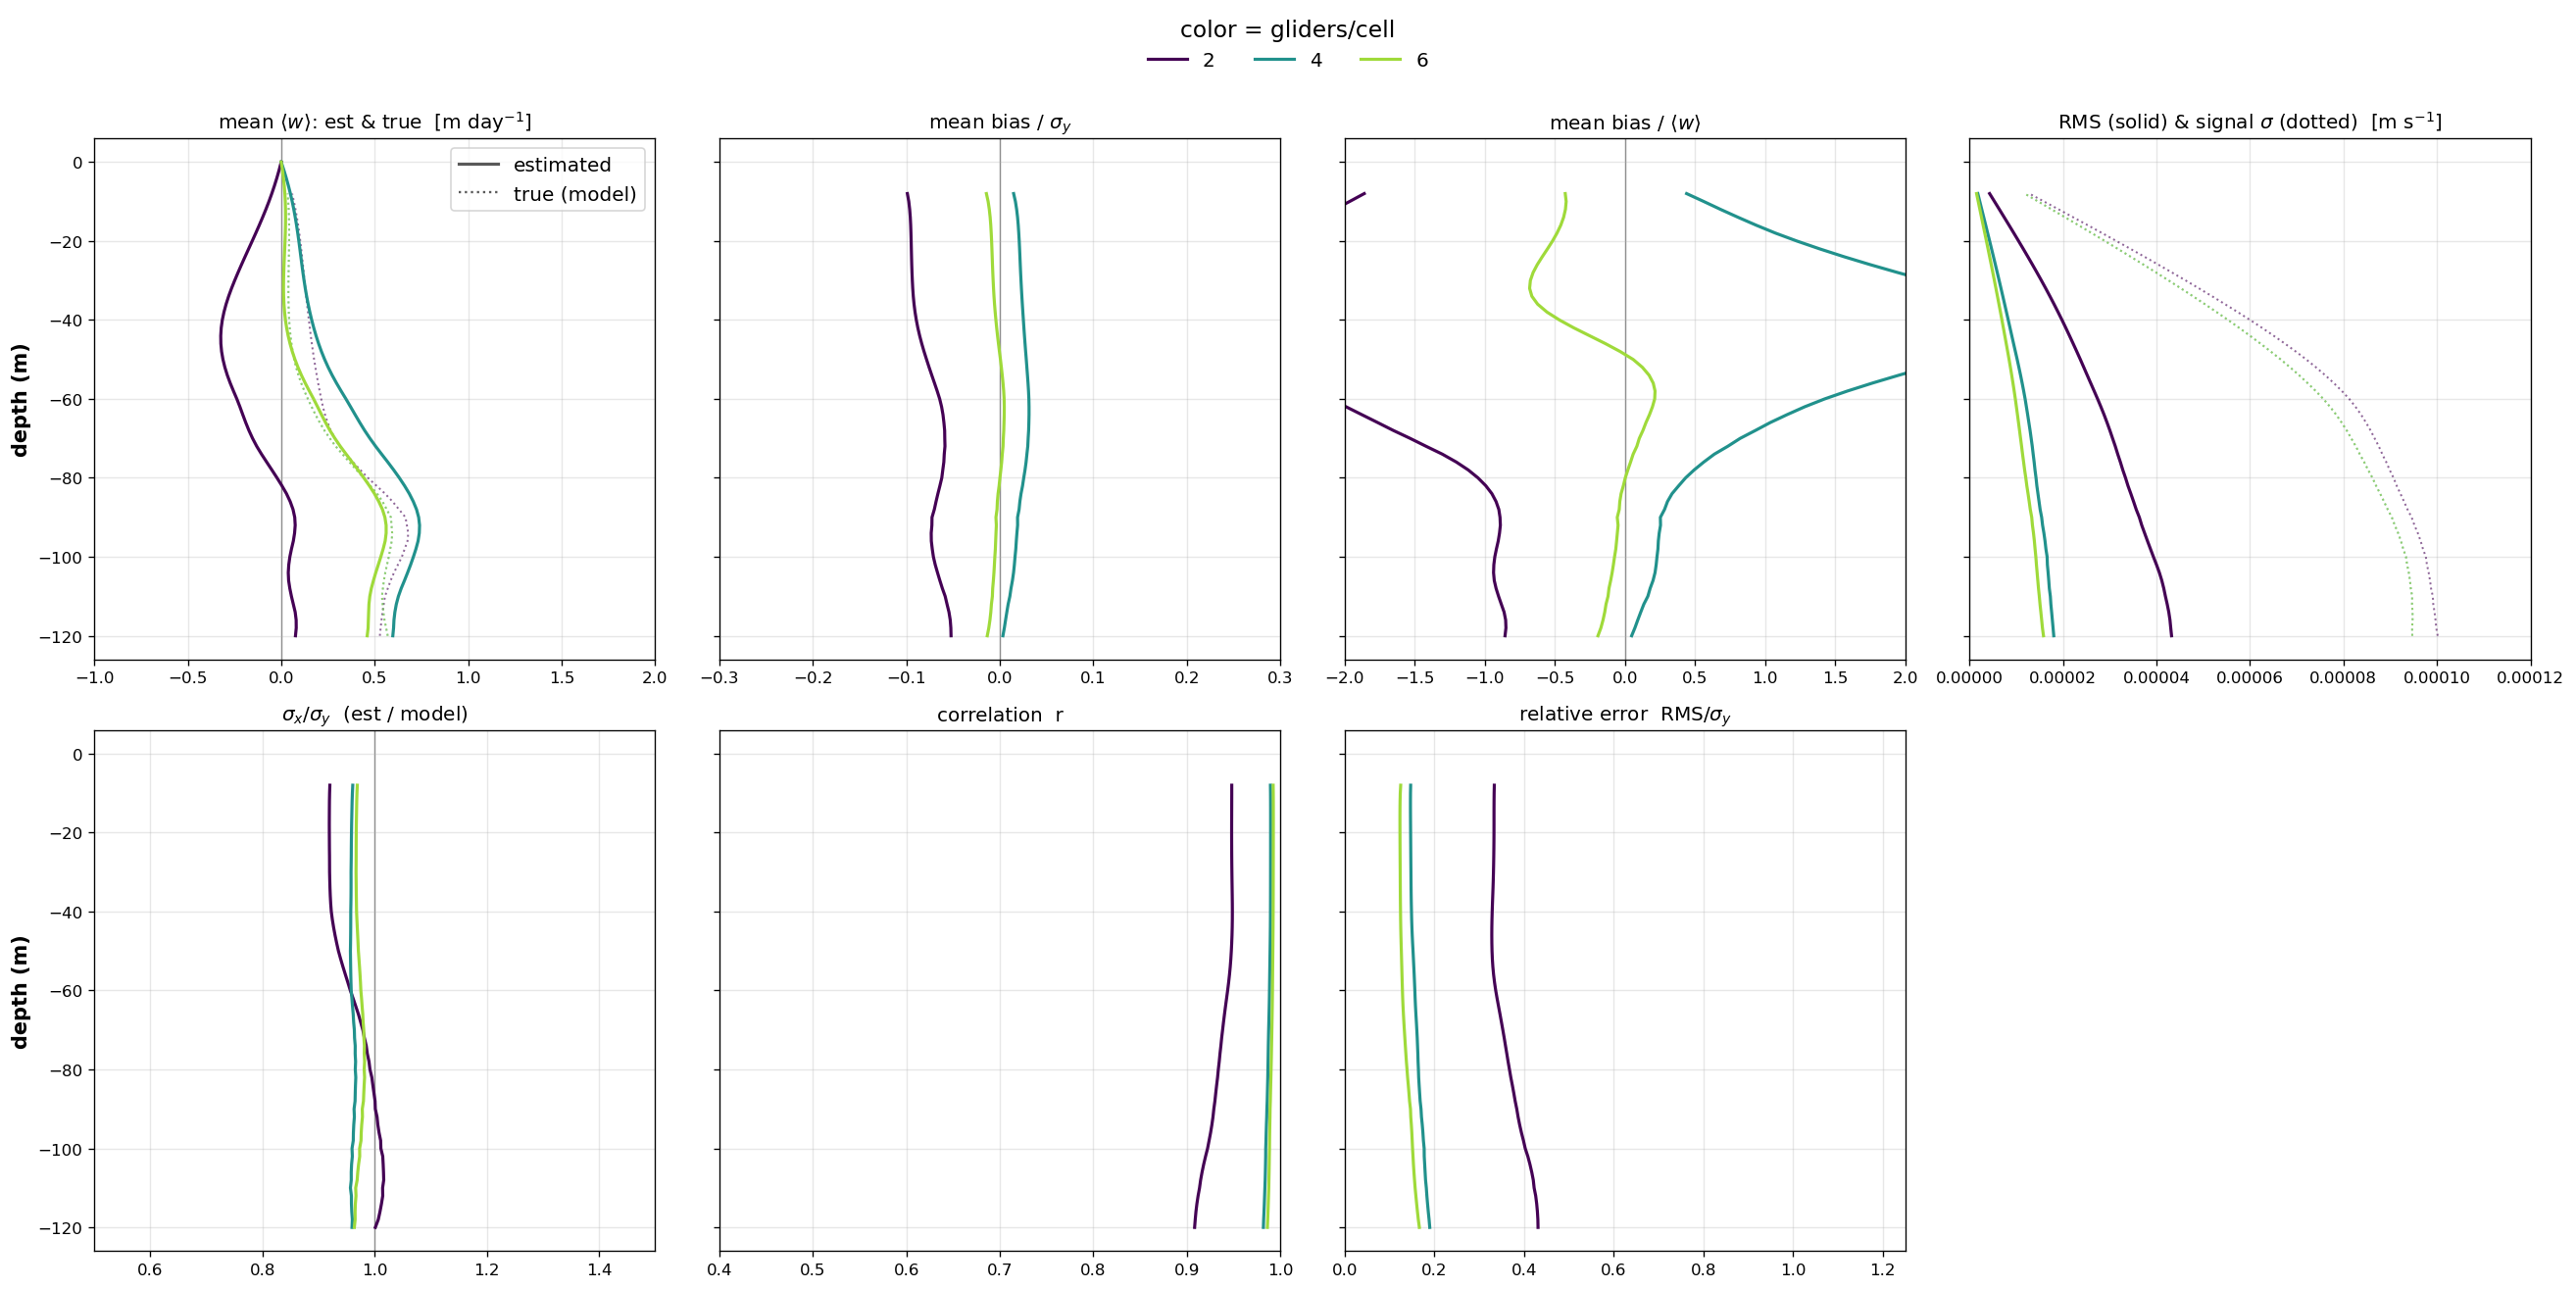

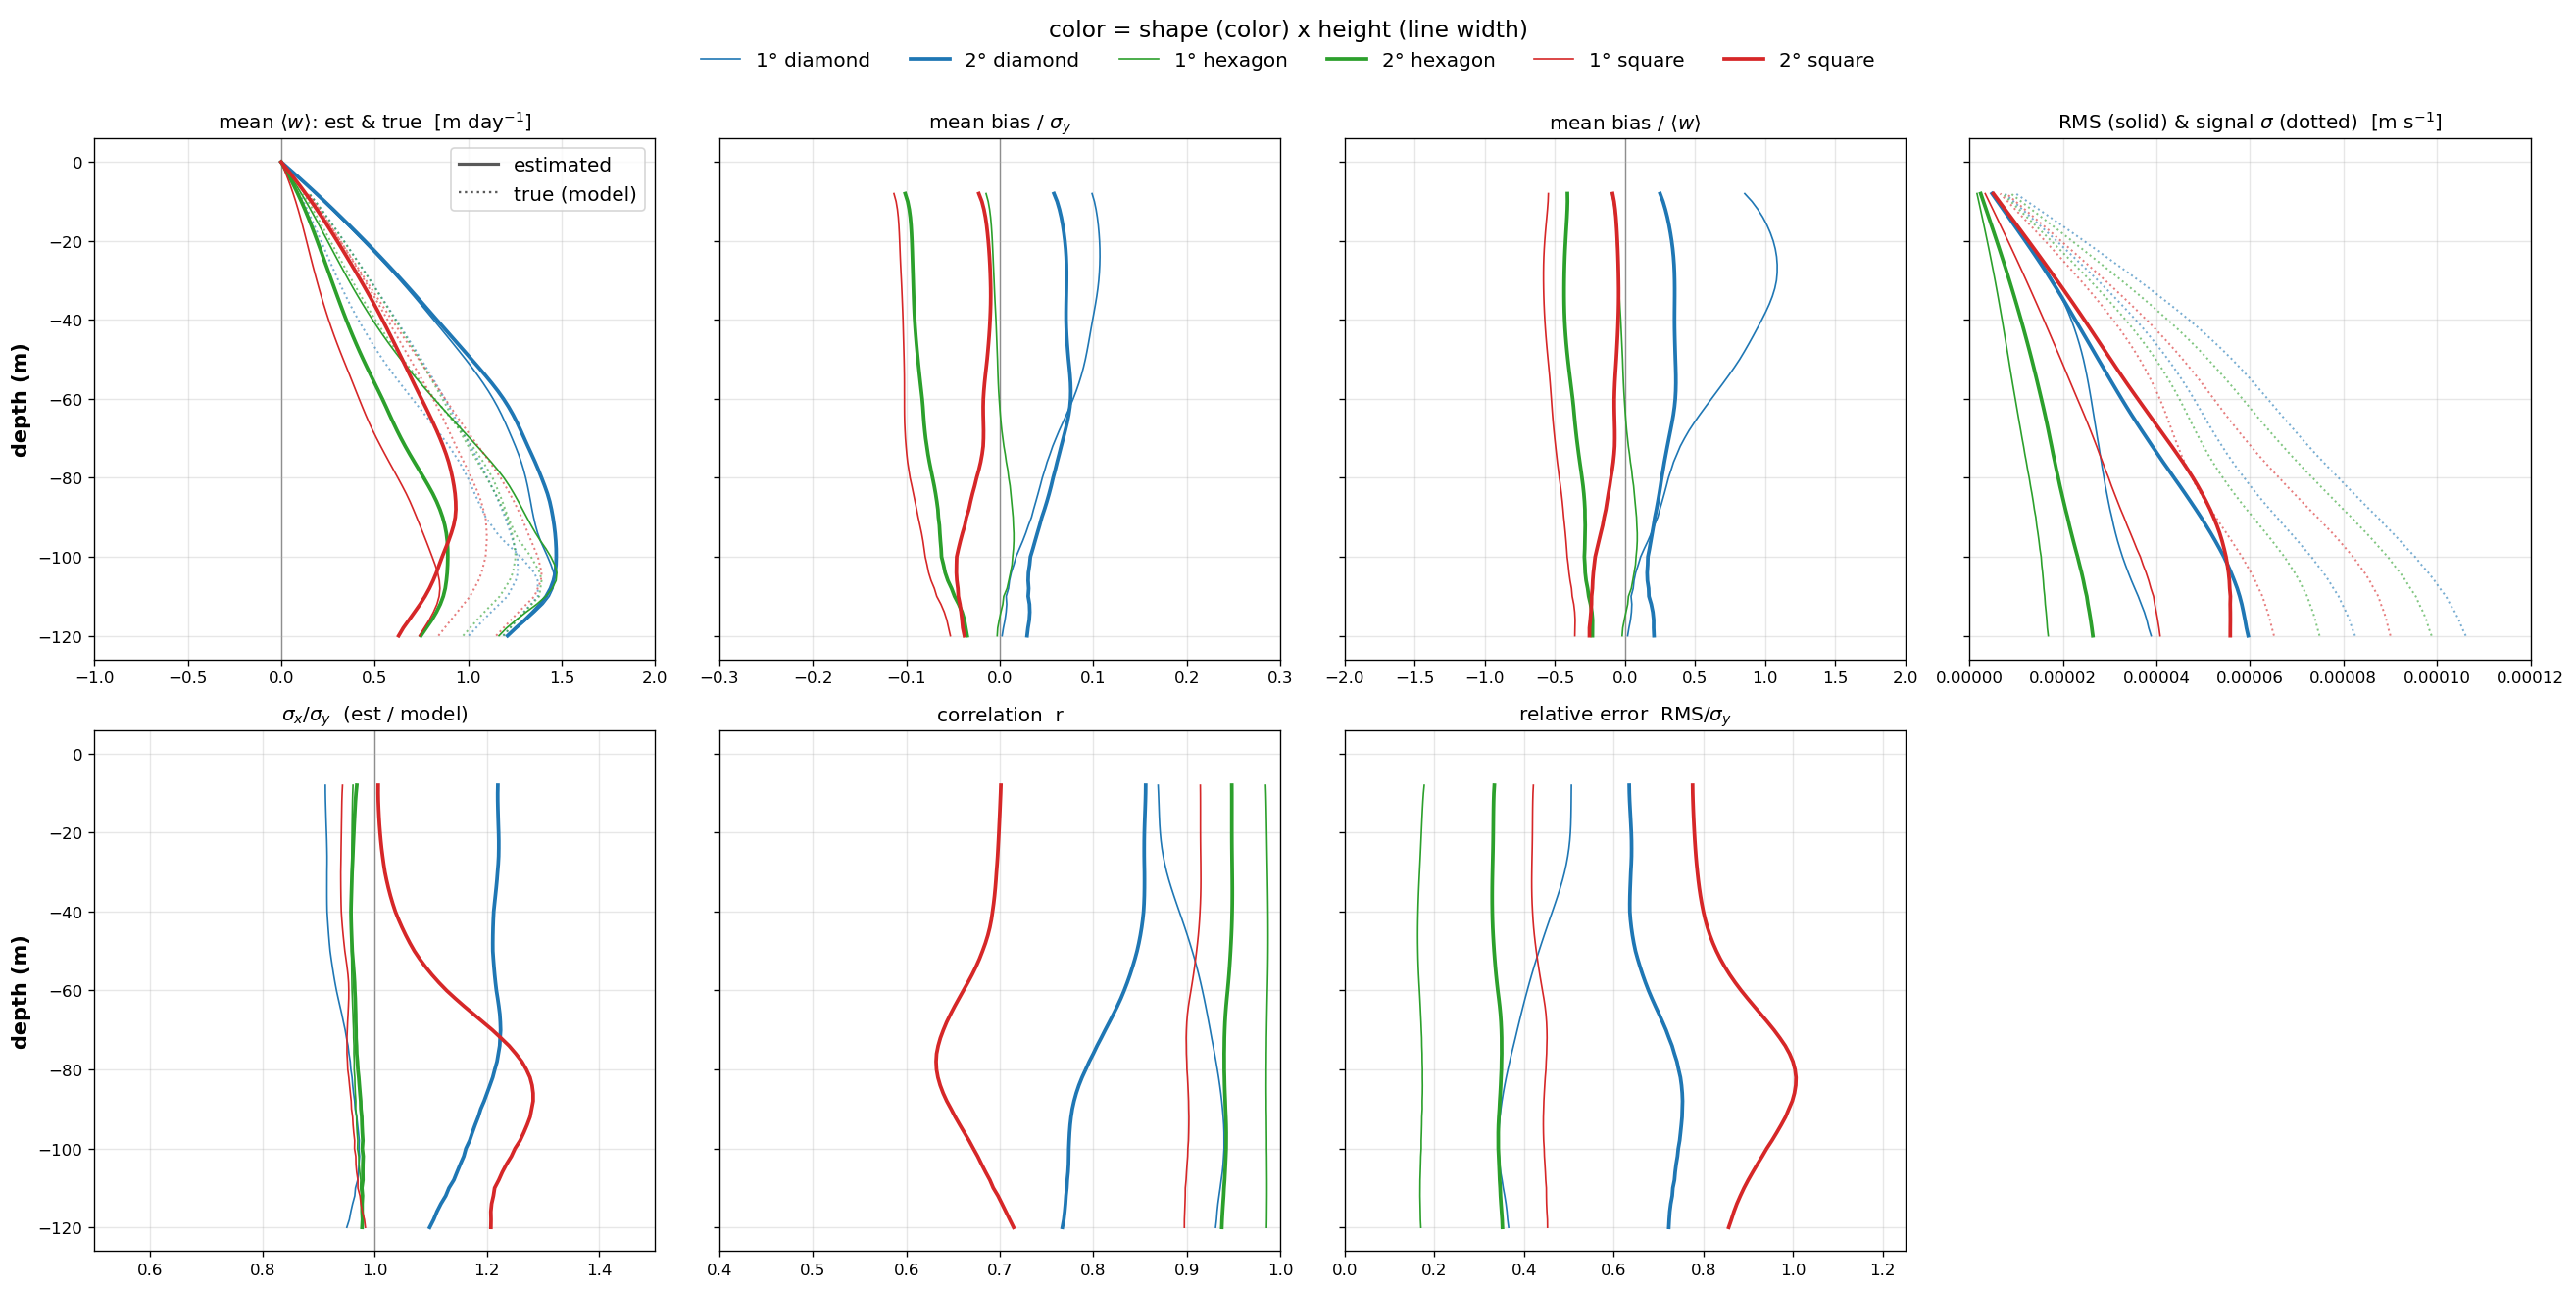

In [7]:
sft.make_fig5(m, SUMDIR, load_cell)

## Figure 6 - metric heatmaps (all configs at a glance)

One "colored square" per (config cell, width) so visual patterns across the
sweep are immediately readable. Rows are estimate cells (sampling pattern @
center latitude, grouped by family), columns are glider lon offset (array
width). Three panels for the three skill metrics: RMS/sigma (lower better),
correlation (higher better), and mean bias / sigma (0 = unbiased). Color is
a scan aid layered on the printed value; sequential maps run light = good ->
dark = poor, the diverging bias map is white at zero. Still plain descriptive
stats - no thresholds or 'best config' calls.

**Figures 6a-6d** repeat this grid one method at a time (same split as fig2a-2d / fig5a-5d): 6a shift, 6b equator 3-cell, 6c density, 6d equator single-cell. Each sub-figure auto-scales its own color range, so read color within a figure; the printed values stay directly comparable to fig6.

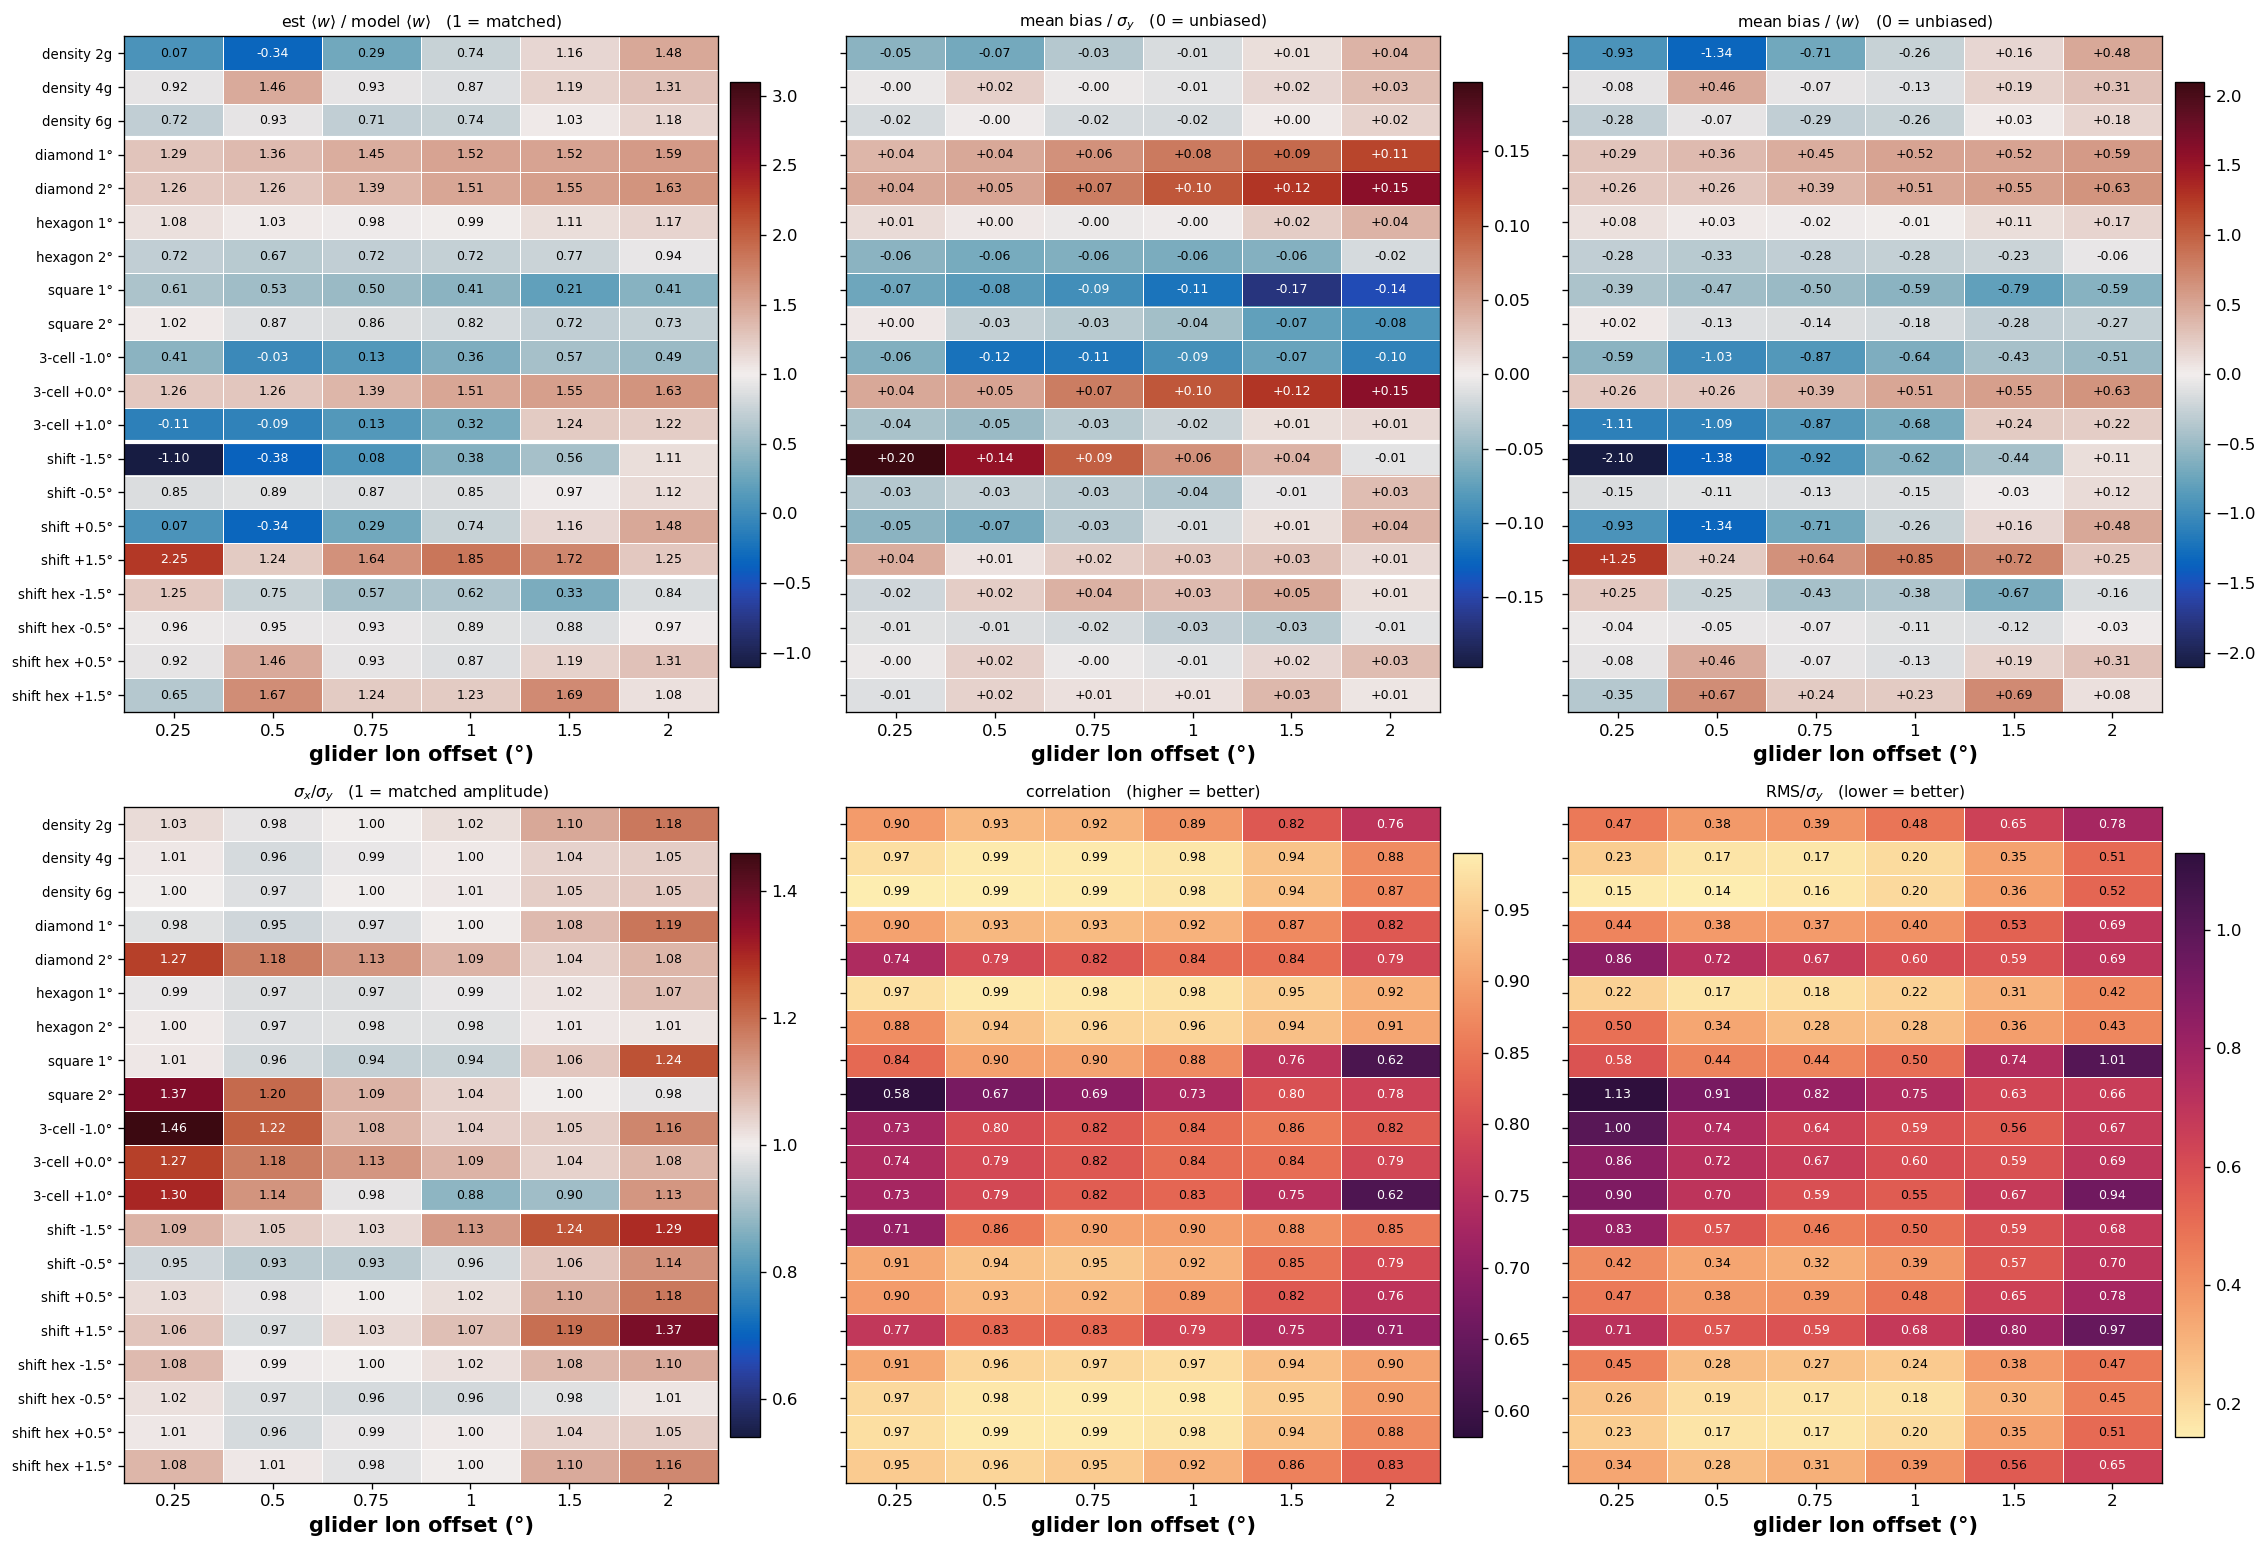

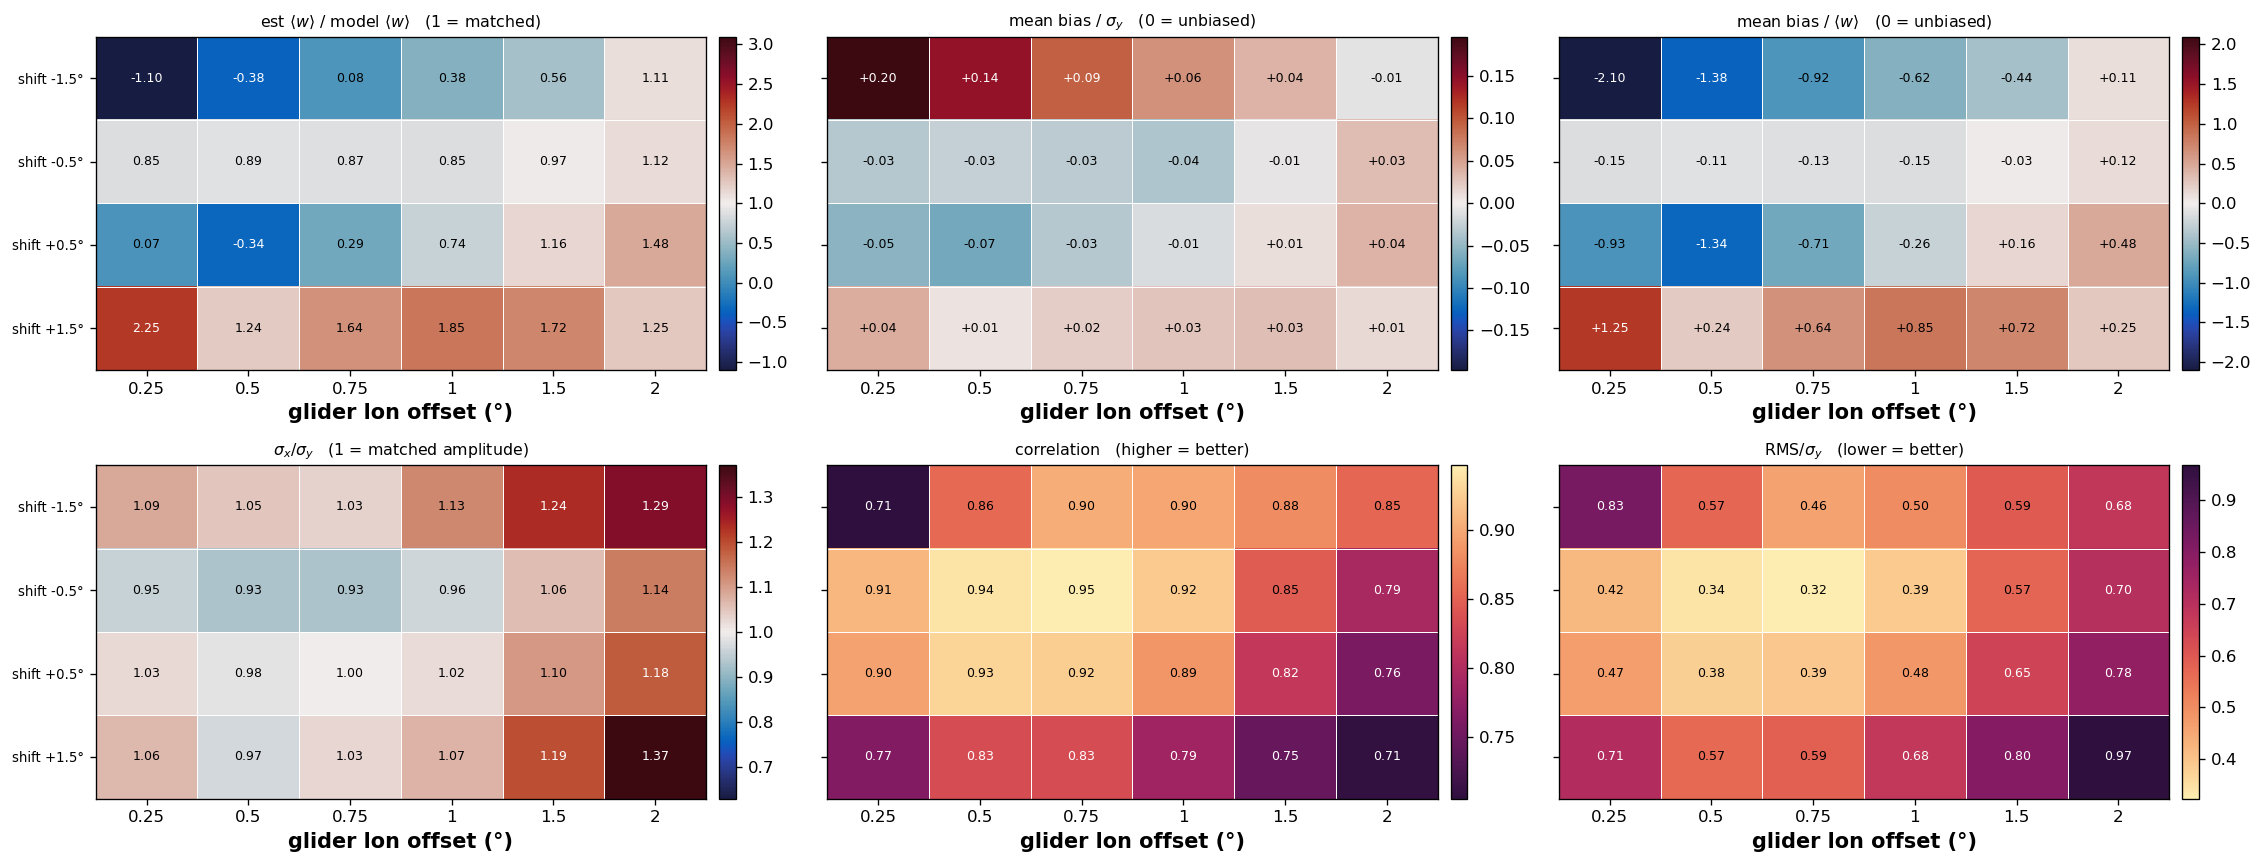

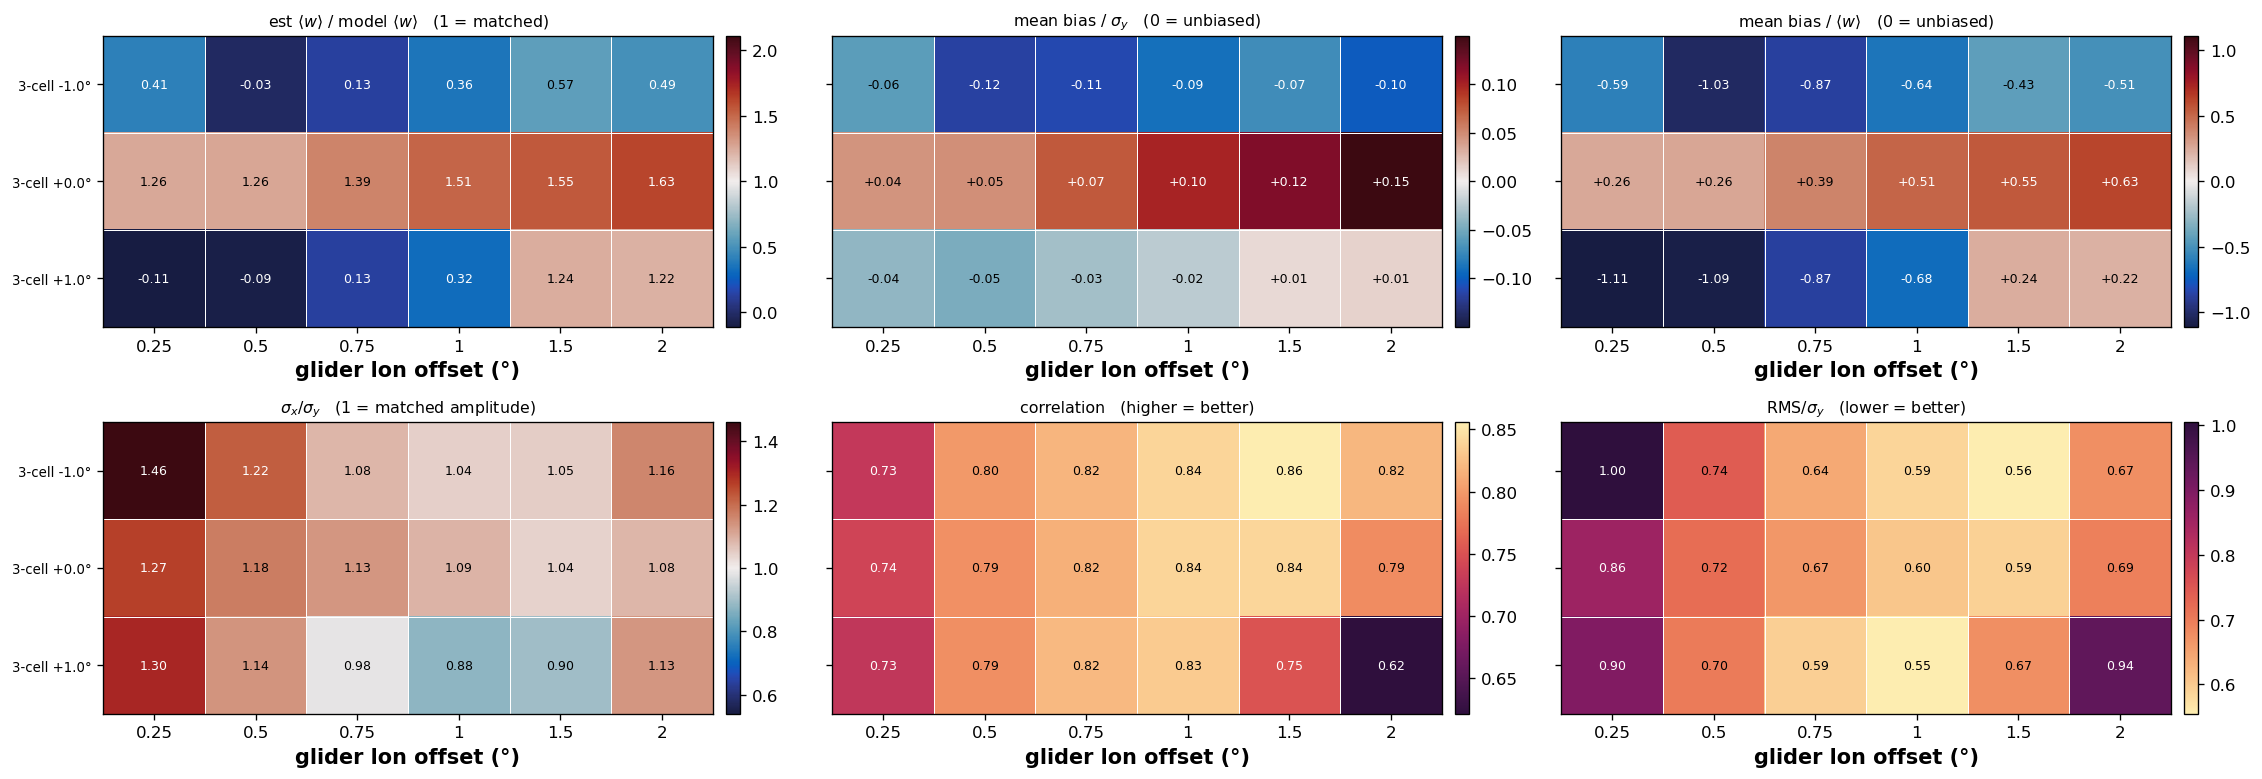

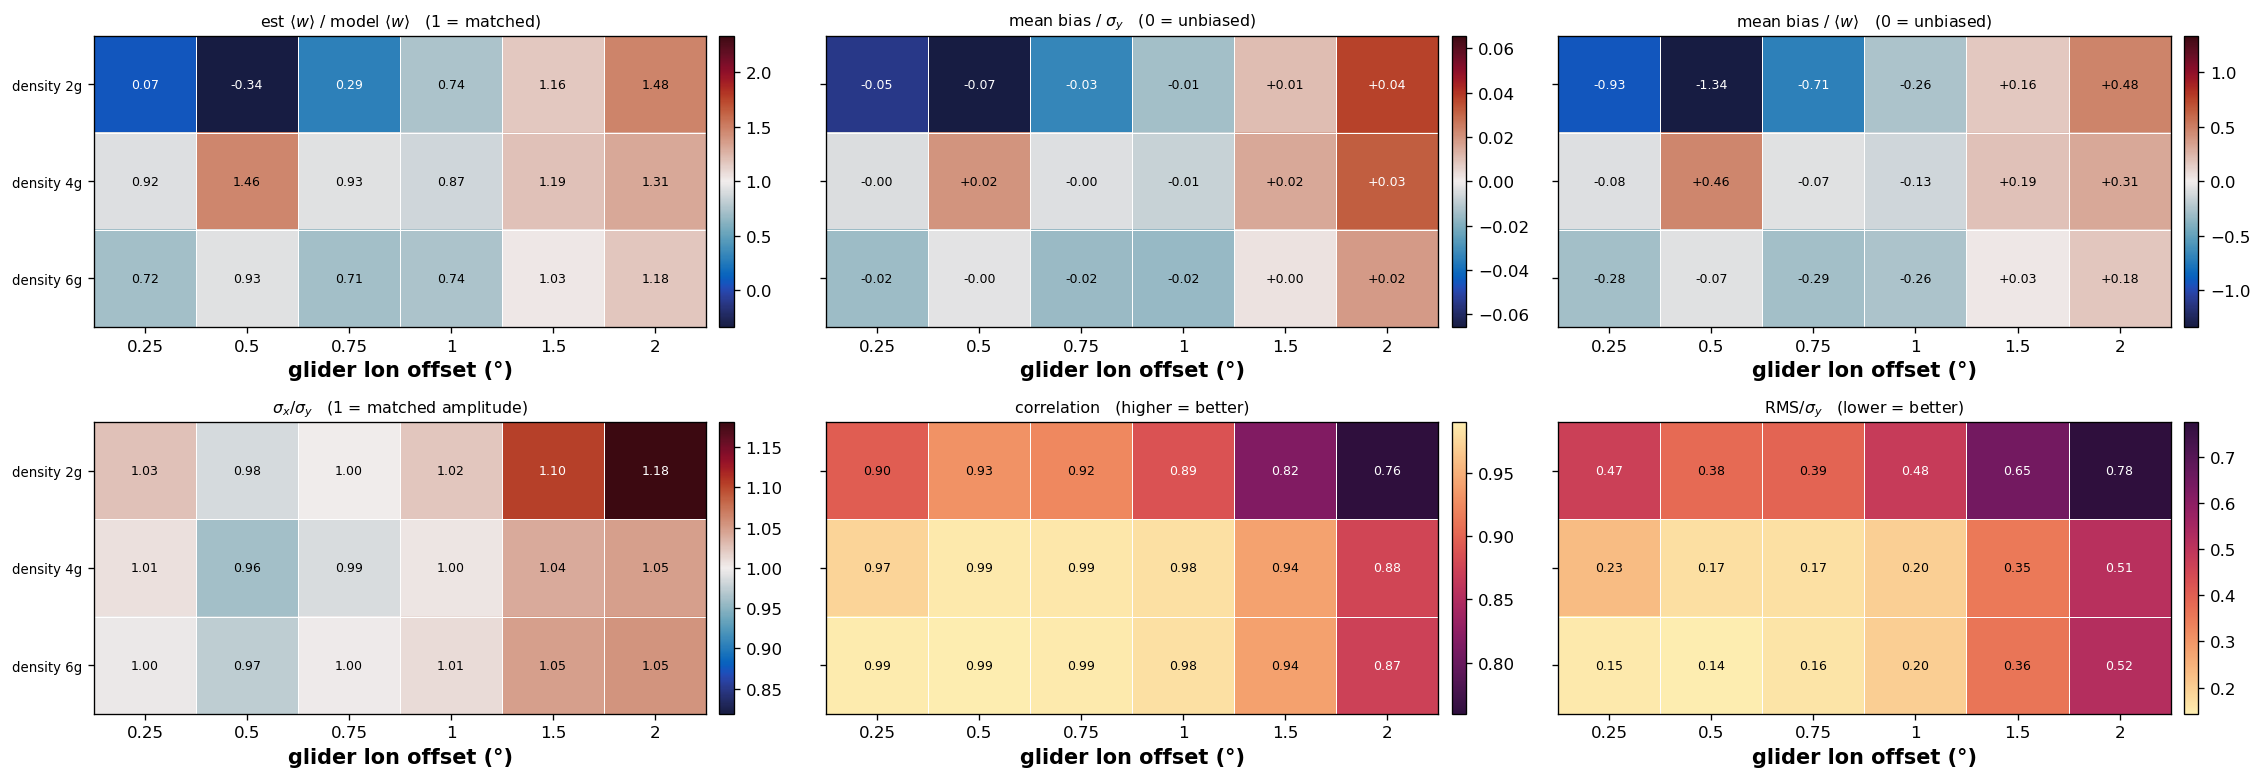

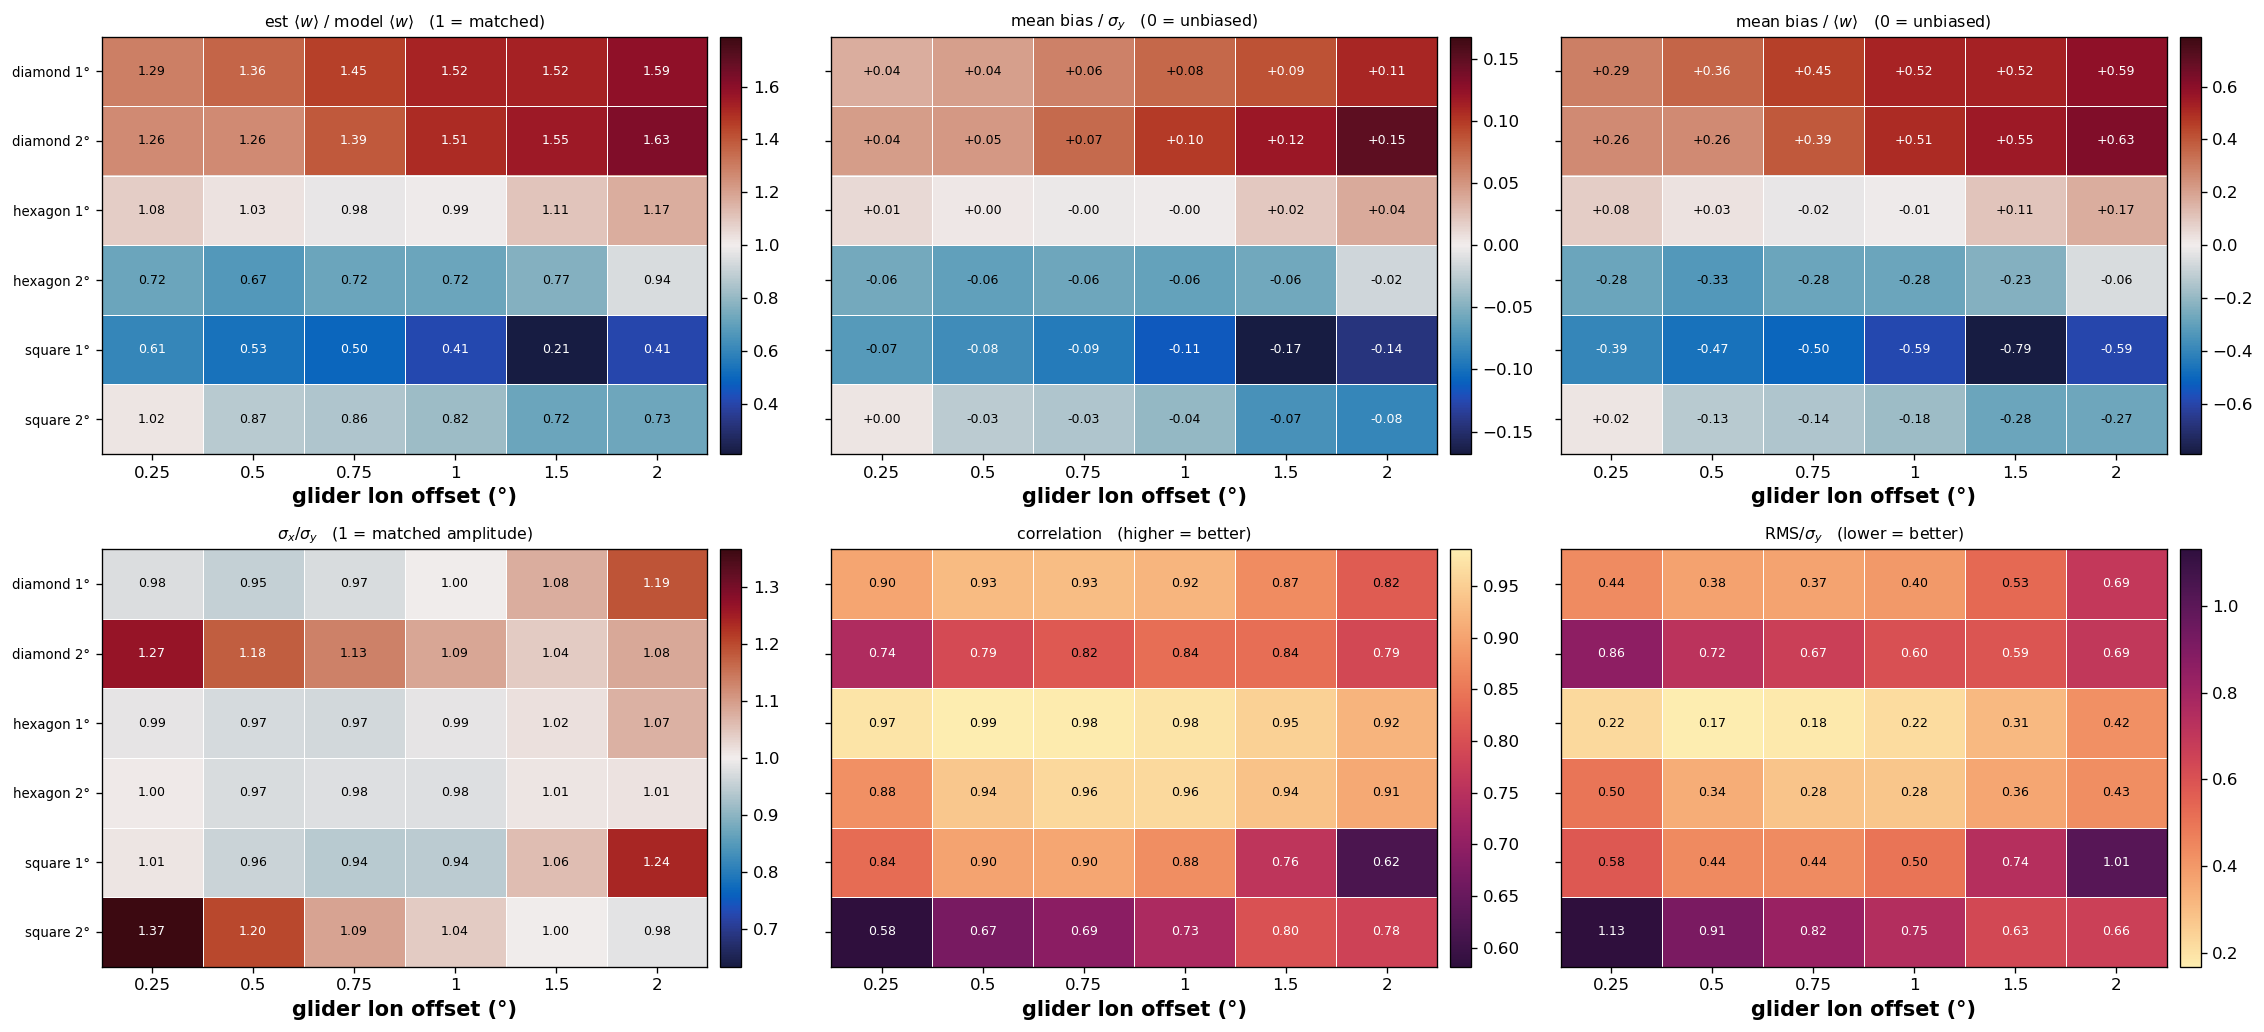

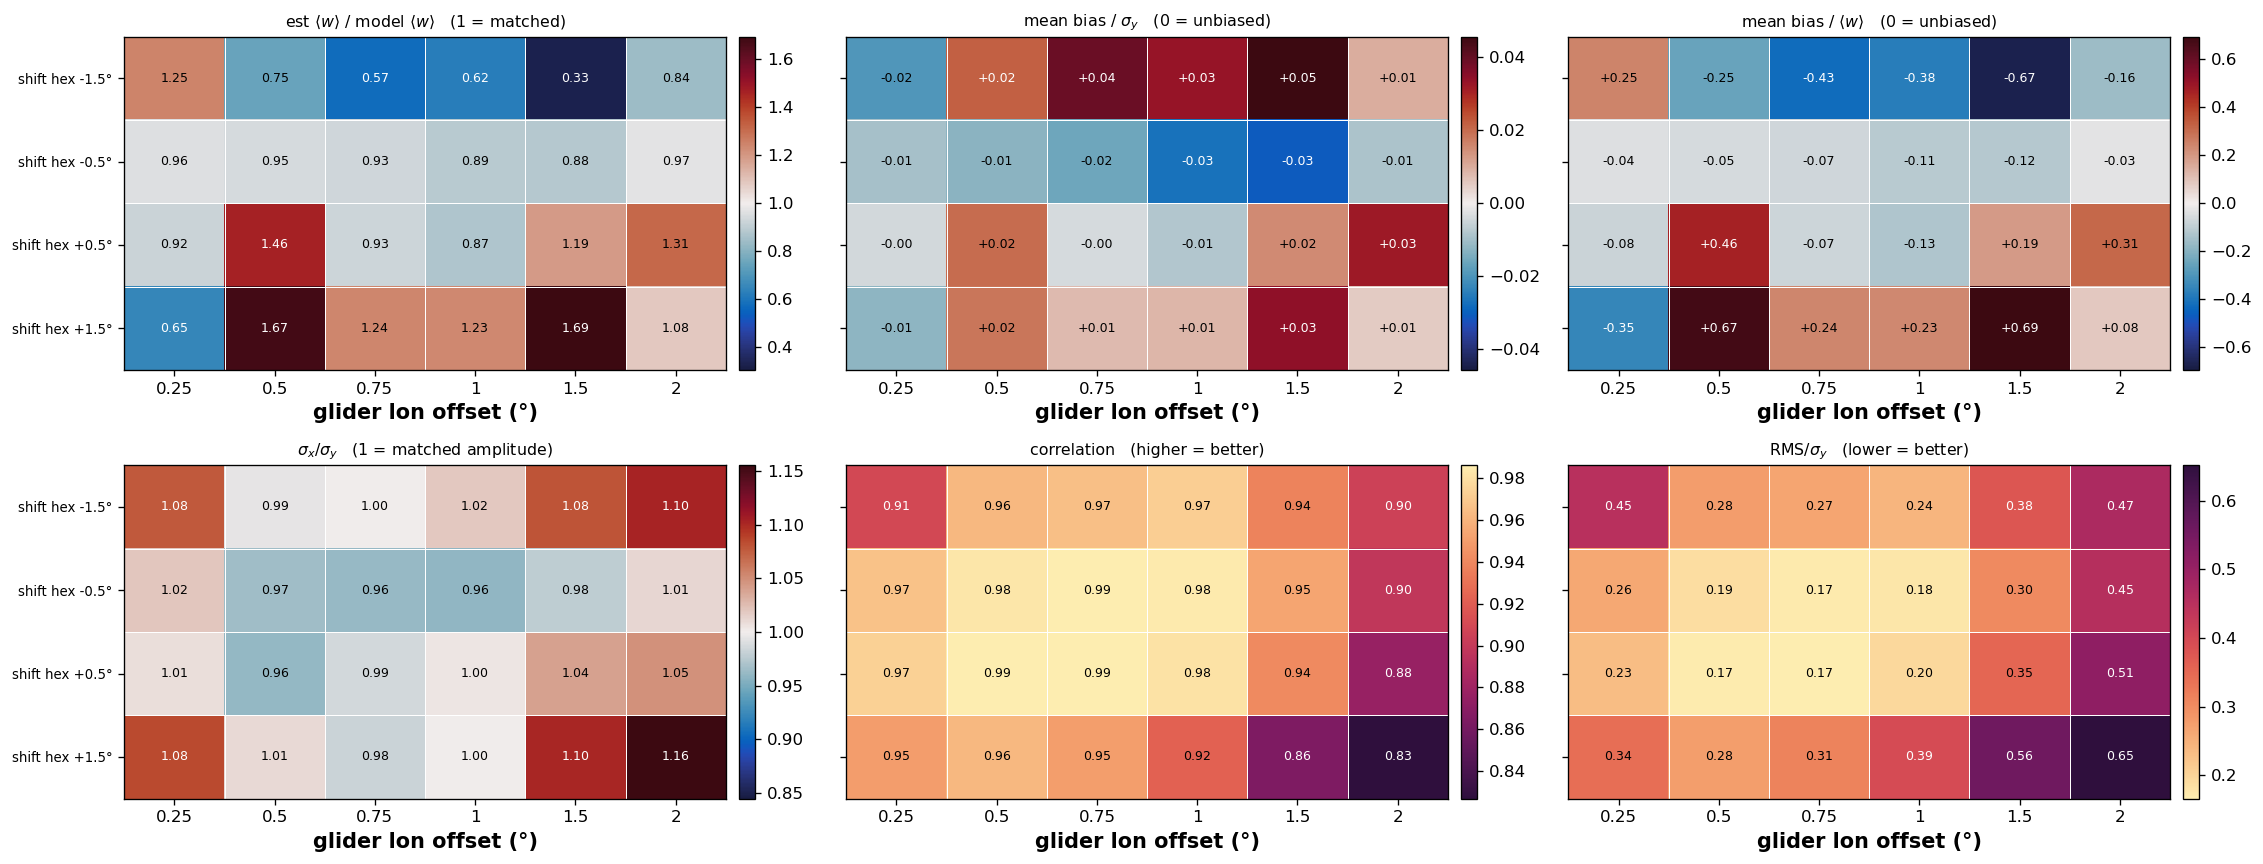

In [8]:
sft.make_fig6(m, SUMDIR)

## Figures 7a-7e - time-mean vertical velocity with confidence intervals

How well the time-mean upwelling is resolved and reproduced, per method group
(same split as fig5). For each config: a depth profile of the estimated (solid)
and true/model (dotted) time-mean \<w\>, each with a shaded +/-1.96*SE band;
plus a "total over depth" panel collapsing the column to one estimate and one
true \<w\> +/- CI per config.

The standard error is autocorrelation-aware: w decorrelates in ~1 day, so the
648-step record holds only N_eff = N/tau ~ 30-70 effectively independent samples,
and the naive SE would understate the uncertainty ~3x. The CI is a statement
about the expected / long-run mean (this window is one autocorrelated sample of
the process); the exact within-window average has no sampling error. Read it two
ways: a band that straddles zero means this record does not resolve a nonzero
time-mean upwelling, and overlapping est/true bands mean the estimate is
statistically consistent with truth. (The tighter paired-difference test lives in
the metrics column `mean_bias_se`.)

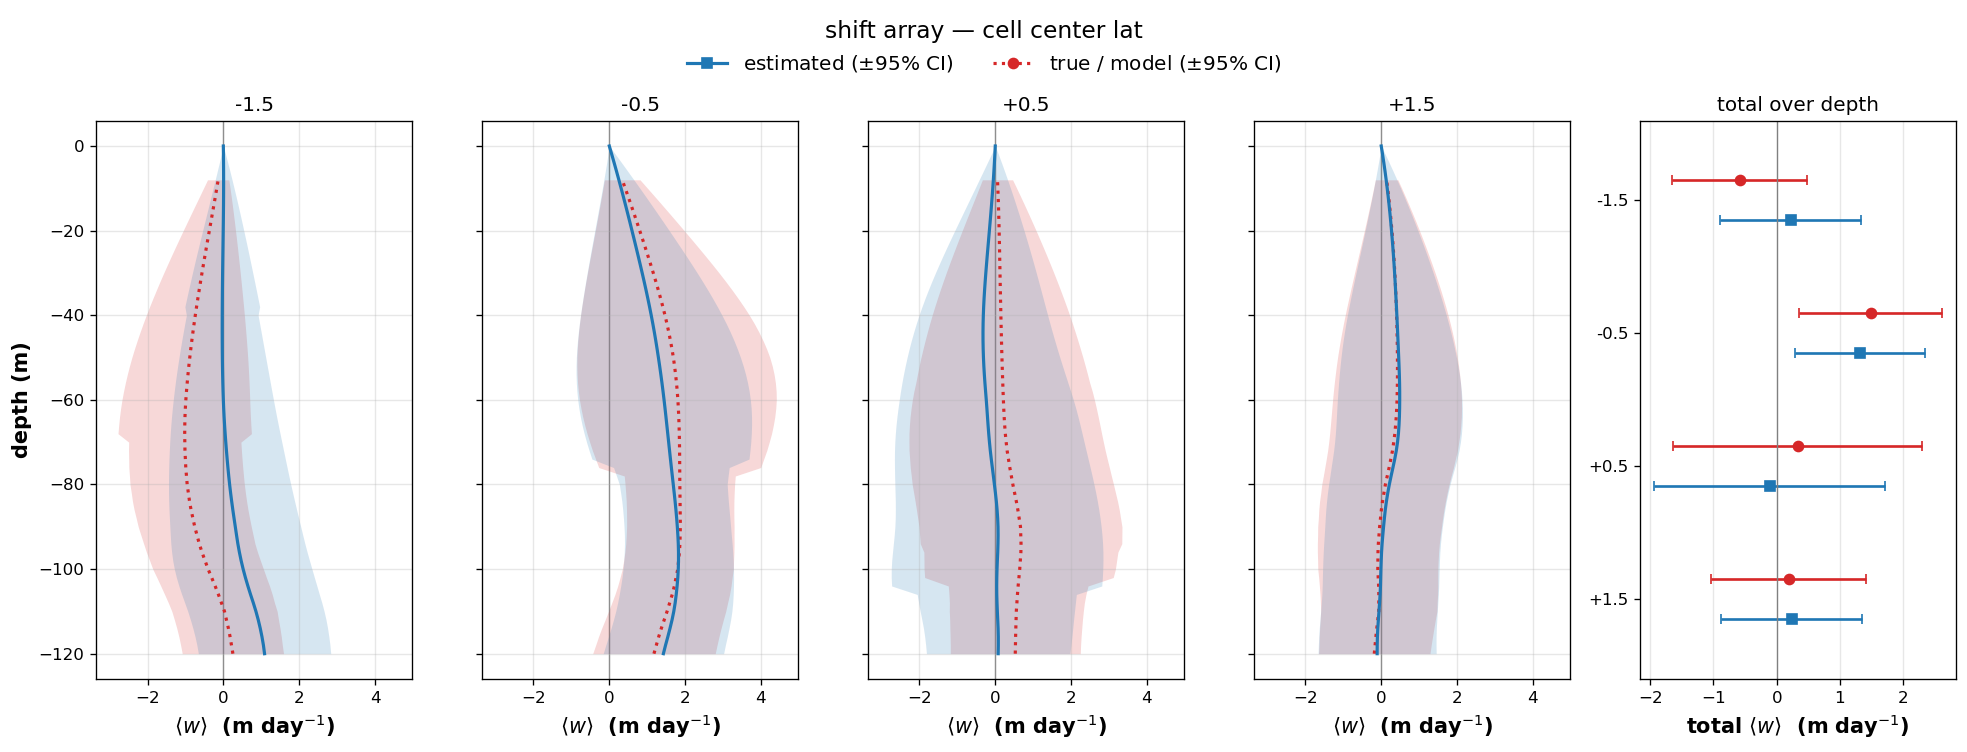

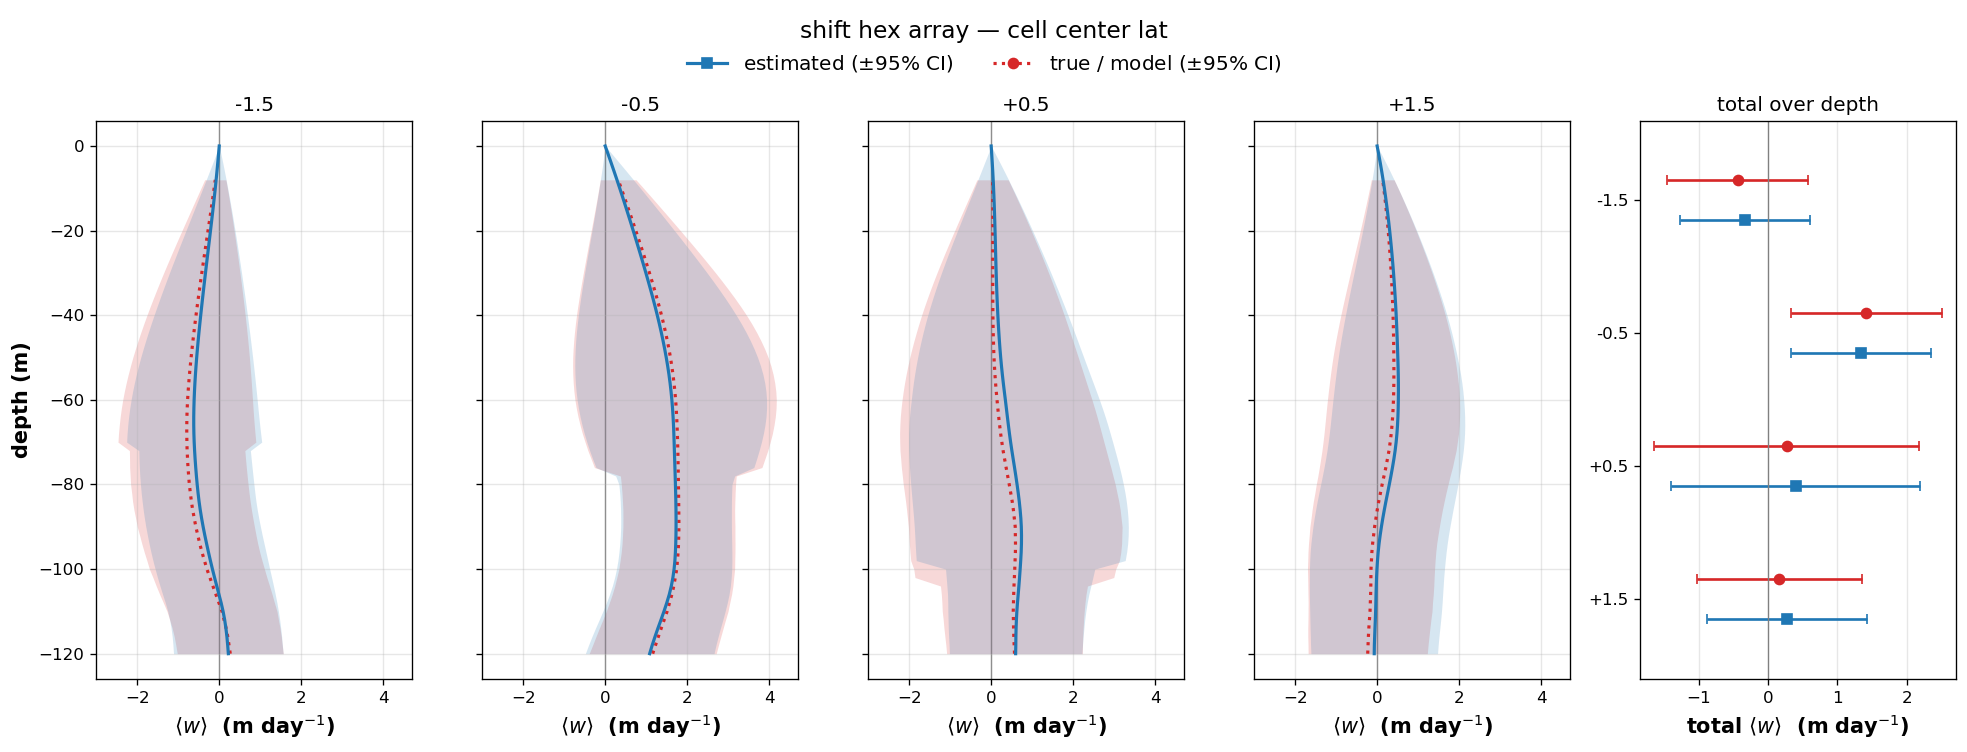

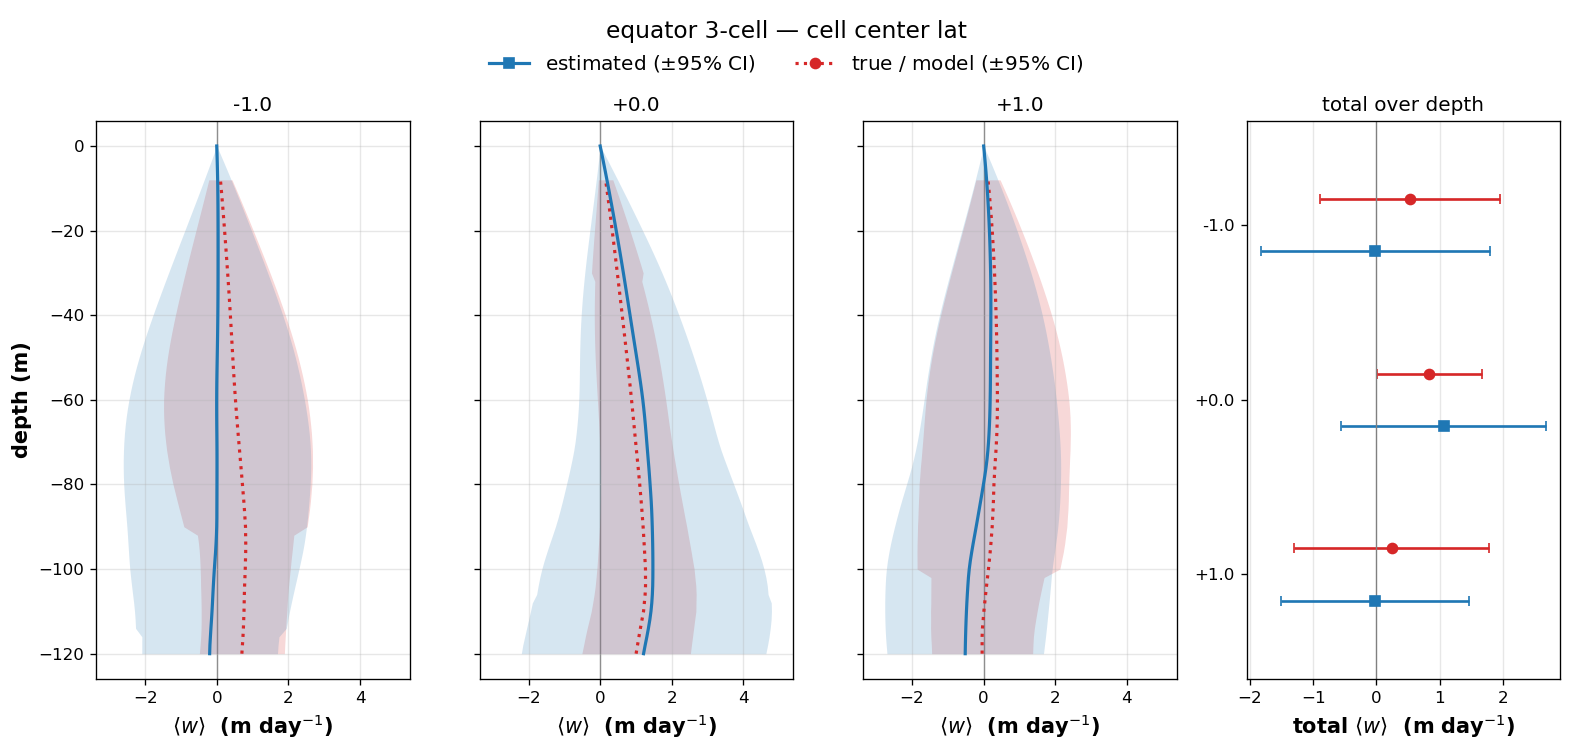

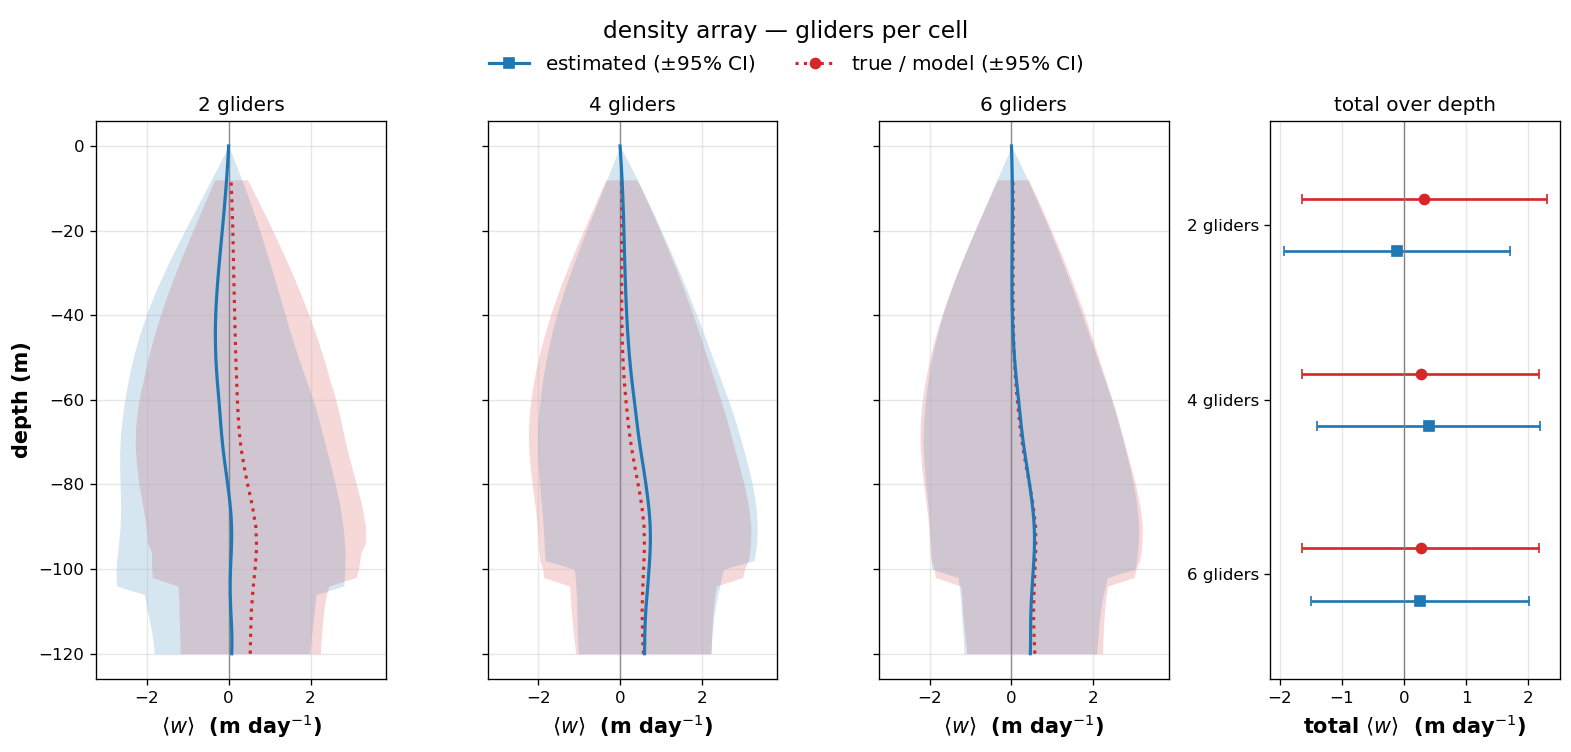

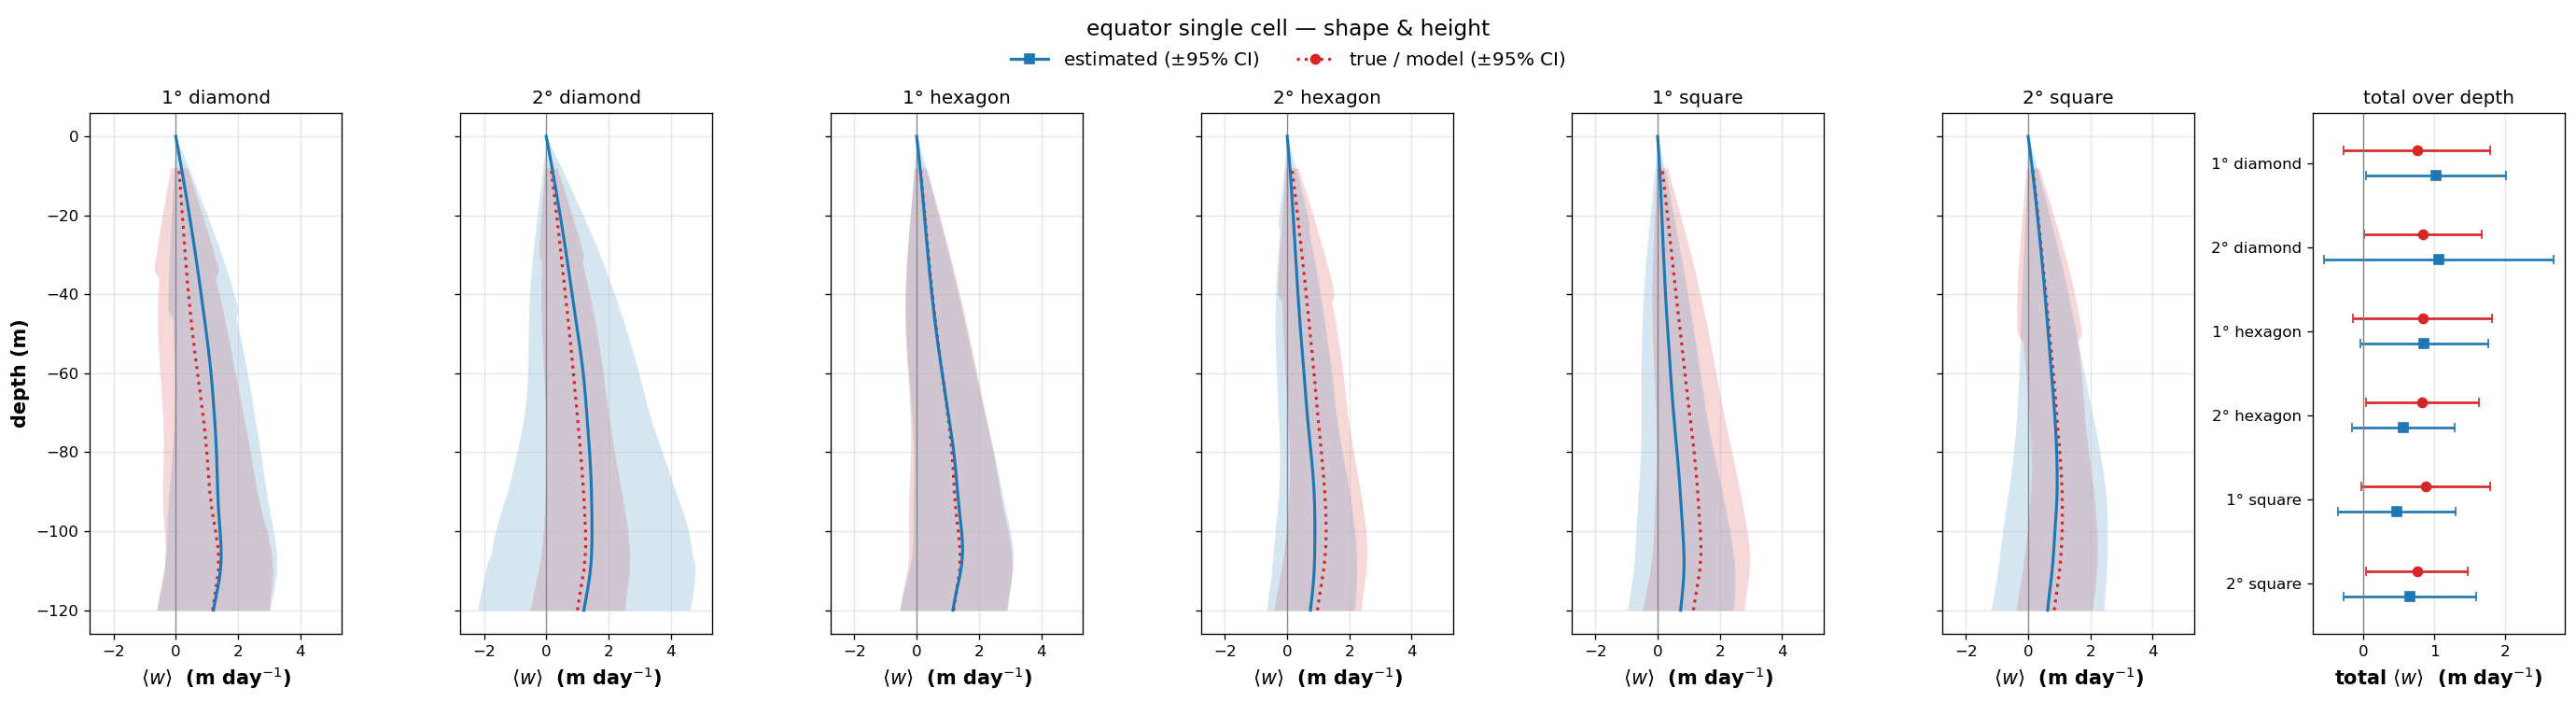

In [9]:
sft.make_fig7(m, SUMDIR, load_cell)